# Acquisition 분석 보고서

In [1]:
!pip install adjustText -qq
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import koreanize_matplotlib
import platform
from sqlalchemy import create_engine

print("성공!")

성공!


In [2]:
import os
from dotenv import load_dotenv, find_dotenv
from sqlalchemy import create_engine

# 접속 정보는 코드에 두지 않는다. 저장소 루트의 .env 에서 읽어온다.
# 최초 1회: .env.example 를 .env 로 복사한 뒤 RECRUIT_DB_URL 을 채울 것.
load_dotenv(find_dotenv(usecwd=True))
engine = create_engine(os.environ["RECRUIT_DB_URL"])


## 1. 개요

### 1-1. 분석 목적 및 배경

채용 플랫폼에 처음 유입된 사용자가 회원가입을 완료하기까지의 과정(Acquisition)을 분석한다. 가입 퍼널의 병목 구간, 가입 소요 시간, 유입 경로, 시계열/북마크 행동, 가입 유도 공고 특성을 통해 어떤 요인이 신규 가입 전환에 영향을 주는지 파악하는 것을 목적으로 한다.

### 1-2. 분석 기간 및 데이터 소스

- **분석 기간**: 2022-01-01 ~ 2023-12-31
- **데이터 소스**: MySQL `log_2022`/`log_2023`(서버 행동 로그), `JobBookmark`, `Job`, `Company` 테이블

### 1-3. 핵심 요약 (Executive Summary)

- 가입 퍼널은 detail → step1 → step2 → step3/done 순으로 진행되며, 단계별 이탈이 발생한다.
- 가입 완료 유저의 중앙값 소요 시간은 2분 16초로 대부분 빠르게 완료하지만, 평균은 이상치의 영향으로 3.1일까지 늘어난다.
- CRM 알림/이메일이 가입 전환의 핵심 유입 경로이며, 가입 완료 후 북마크의 지원 전환율이 전체 대비 2.3배 높다.

### 1-4. CTE 정의

In [3]:
signup_cte = """
WITH logs AS (
    SELECT user_uuid, timestamp, URL, response_code, method
    FROM log_2022
    WHERE user_uuid IS NOT NULL
      AND response_code NOT IN (400, 404, 500) -- 모든 단계 공통: 에러 제외

    UNION ALL

    SELECT user_uuid, timestamp, URL, response_code, method
    FROM log_2023
    WHERE user_uuid IS NOT NULL
      AND response_code NOT IN (400, 404, 500) -- 모든 단계 공통: 에러 제외
),

step_detail_users AS (
    SELECT
        user_uuid,
        MIN(timestamp) AS detail_time
    FROM logs
    WHERE URL LIKE '%%signup/detail%%'
    GROUP BY user_uuid
),

step1_users AS (
    SELECT
        l.user_uuid,
        MIN(l.timestamp) AS step1_time
    FROM logs l
    INNER JOIN step_detail_users d
        ON l.user_uuid = d.user_uuid
       AND l.timestamp >= d.detail_time
    WHERE l.URL LIKE '%%signup/step1%%'
    GROUP BY l.user_uuid
),

step2_users AS (
    SELECT
        l.user_uuid,
        MIN(l.timestamp) AS step2_time
    FROM logs l
    INNER JOIN step1_users s1
        ON l.user_uuid = s1.user_uuid
       AND l.timestamp >= s1.step1_time
    WHERE l.URL LIKE '%%signup/step2%%'
    GROUP BY l.user_uuid
),

step3_done_users AS (
    SELECT
        l.user_uuid,
        MIN(l.timestamp) AS done_time
    FROM logs l
    INNER JOIN step2_users s2
        ON l.user_uuid = s2.user_uuid
       AND l.timestamp >= s2.step2_time
    WHERE l.URL LIKE '%%signup/step3/done%%'
      AND l.response_code = 200 -- ★ 스텝3 완료는 오직 200인 것만 인정
    GROUP BY l.user_uuid
)
"""

In [4]:
bookmark_cte = signup_cte + """
-- ---------- 가입 완료 후 북마크 한 유저 ----------
, signup_bookmark_users AS (

    SELECT
        s3.user_uuid,
        jb.job_uuid,
        jb.cdate AS bookmark_time
    FROM step3_done_users s3

    INNER JOIN jobbookmark jb
        ON s3.user_uuid = jb.user_uuid

)
"""

## 2. 회원가입 퍼널 분석

### 2-1. 전체 퍼널 전환율 개요

In [5]:
# 기준점
query = signup_cte + """
SELECT
    COUNT(DISTINCT d.user_uuid) AS funnel_1_detail_users,
    COUNT(DISTINCT s1.user_uuid) AS funnel_2_step1_users,
    COUNT(DISTINCT s2.user_uuid) AS funnel_3_step2_users,
    COUNT(DISTINCT s3.user_uuid) AS funnel_4_done_users
FROM step_detail_users d
LEFT JOIN step1_users s1
    ON d.user_uuid = s1.user_uuid
LEFT JOIN step2_users s2
    ON d.user_uuid = s2.user_uuid
LEFT JOIN step3_done_users s3
    ON d.user_uuid = s3.user_uuid
"""

funnel = pd.read_sql(query, engine)
funnel

### 2-2. 단계별 이탈률 및 병목 구간 식별

In [6]:
# 이탈률 파악
detail = funnel.loc[0, 'funnel_1_detail_users']
step1 = funnel.loc[0, 'funnel_2_step1_users']
step2 = funnel.loc[0, 'funnel_3_step2_users']
done = funnel.loc[0, 'funnel_4_done_users']

drop_df = pd.DataFrame({
    '구간': [
        'funnel_1_detail_users → funnel_2_step1_users',
        'funnel_2_step1_users → funnel_3_step2_users',
        'funnel_3_step2_users → funnel_4_done_users'
    ],
    '이전단계_유저수': [
        detail,
        step1,
        step2
    ],
    '다음단계_유저수': [
        step1,
        step2,
        done
    ]
})

drop_df['이탈유저수'] = (
    drop_df['이전단계_유저수']
    - drop_df['다음단계_유저수']
)

drop_df['이탈률(%)'] = round(
    drop_df['이탈유저수']
    / drop_df['이전단계_유저수']
    * 100,
    2
)

drop_df

In [7]:
query = signup_cte + """
SELECT
    COUNT(DISTINCT d.user_uuid) AS funnel_1_detail_users,
    COUNT(DISTINCT s1.user_uuid) AS funnel_2_step1_users,
    COUNT(DISTINCT s2.user_uuid) AS funnel_3_step2_users,
    COUNT(DISTINCT s3.user_uuid) AS funnel_4_done_users
FROM step_detail_users d
LEFT JOIN step1_users s1
    ON d.user_uuid = s1.user_uuid
LEFT JOIN step2_users s2
    ON d.user_uuid = s2.user_uuid
LEFT JOIN step3_done_users s3
    ON d.user_uuid = s3.user_uuid;
"""


REFRESH = False
CACHE_FILE = "_cache/signup_funnel.pkl"

if REFRESH or not os.path.exists(CACHE_FILE):
    df = pd.read_sql(query, engine)
    df.to_pickle(CACHE_FILE)
else:
    df = pd.read_pickle(CACHE_FILE)

### 2-3. 월별 퍼널 추이 (절대값 / 전환율)

In [8]:
# 절대값
query = signup_cte + """
SELECT
    month,

    COUNT(DISTINCT detail_user) AS detail_users,
    COUNT(DISTINCT step1_user) AS step1_users,
    COUNT(DISTINCT step2_user) AS step2_users,
    COUNT(DISTINCT done_user) AS signup_done_users

FROM (

    SELECT
        DATE_FORMAT(detail_time, '%%Y-%%m') AS month,
        user_uuid AS detail_user,
        NULL AS step1_user,
        NULL AS step2_user,
        NULL AS done_user
    FROM step_detail_users

    UNION ALL

    SELECT
        DATE_FORMAT(step1_time, '%%Y-%%m') AS month,
        NULL,
        user_uuid,
        NULL,
        NULL
    FROM step1_users

    UNION ALL

    SELECT
        DATE_FORMAT(step2_time, '%%Y-%%m') AS month,
        NULL,
        NULL,
        user_uuid,
        NULL
    FROM step2_users

    UNION ALL

    SELECT
        DATE_FORMAT(done_time, '%%Y-%%m') AS month,
        NULL,
        NULL,
        NULL,
        user_uuid
    FROM step3_done_users

) t

GROUP BY month
ORDER BY month;
"""

monthly_funnel_df = pd.read_sql(query, engine)
monthly_funnel_df

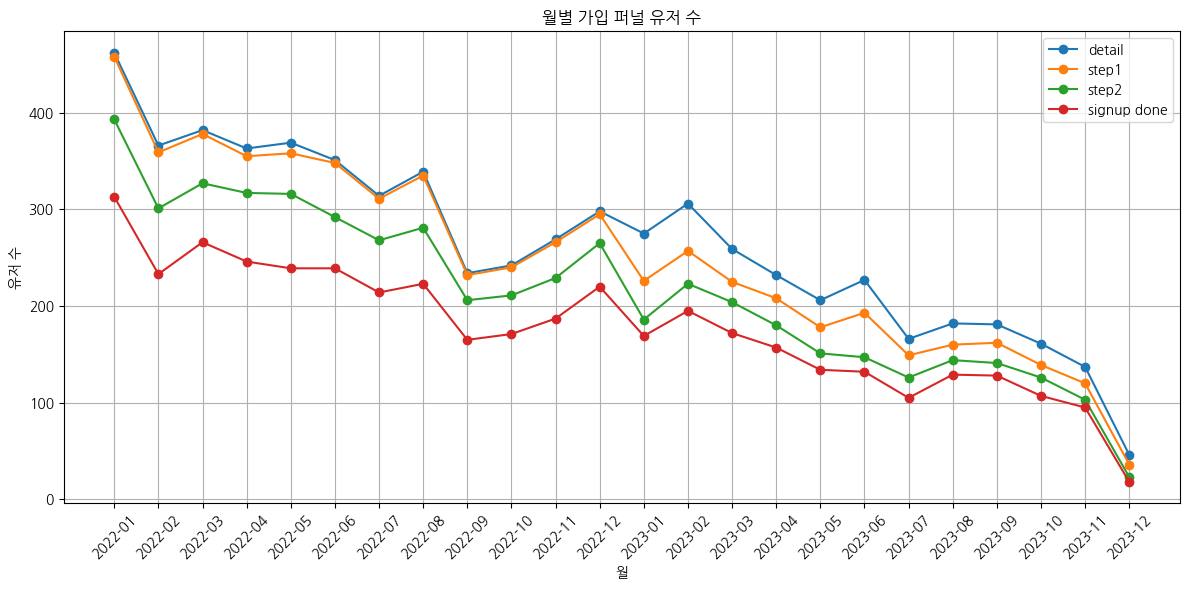

In [9]:
# 시각화

plt.figure(figsize=(12, 6))

plt.plot(monthly_funnel_df['month'], monthly_funnel_df['detail_users'], marker='o', label='detail')
plt.plot(monthly_funnel_df['month'], monthly_funnel_df['step1_users'], marker='o', label='step1')
plt.plot(monthly_funnel_df['month'], monthly_funnel_df['step2_users'], marker='o', label='step2')
plt.plot(monthly_funnel_df['month'], monthly_funnel_df['signup_done_users'], marker='o', label='signup done')

plt.title('월별 가입 퍼널 유저 수')
plt.xlabel('월')
plt.ylabel('유저 수')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

In [10]:
# 비율
monthly_ratio_df = monthly_funnel_df.copy()

monthly_ratio_df['detail_to_step1_rate'] = np.where(
    monthly_ratio_df['detail_users'] == 0,
    np.nan,
    (monthly_ratio_df['step1_users'] / monthly_ratio_df['detail_users'] * 100).round(1)
)

monthly_ratio_df['step1_to_step2_rate'] = np.where(
    monthly_ratio_df['step1_users'] == 0,
    np.nan,
    (monthly_ratio_df['step2_users'] / monthly_ratio_df['step1_users'] * 100).round(1)
)

monthly_ratio_df['step2_to_done_rate'] = np.where(
    monthly_ratio_df['step2_users'] == 0,
    np.nan,
    (monthly_ratio_df['signup_done_users'] / monthly_ratio_df['step2_users'] * 100).round(1)
)

monthly_ratio_df['detail_to_done_rate'] = np.where(
    monthly_ratio_df['detail_users'] == 0,
    np.nan,
    (monthly_ratio_df['signup_done_users'] / monthly_ratio_df['detail_users'] * 100).round(1)
)

monthly_ratio_df

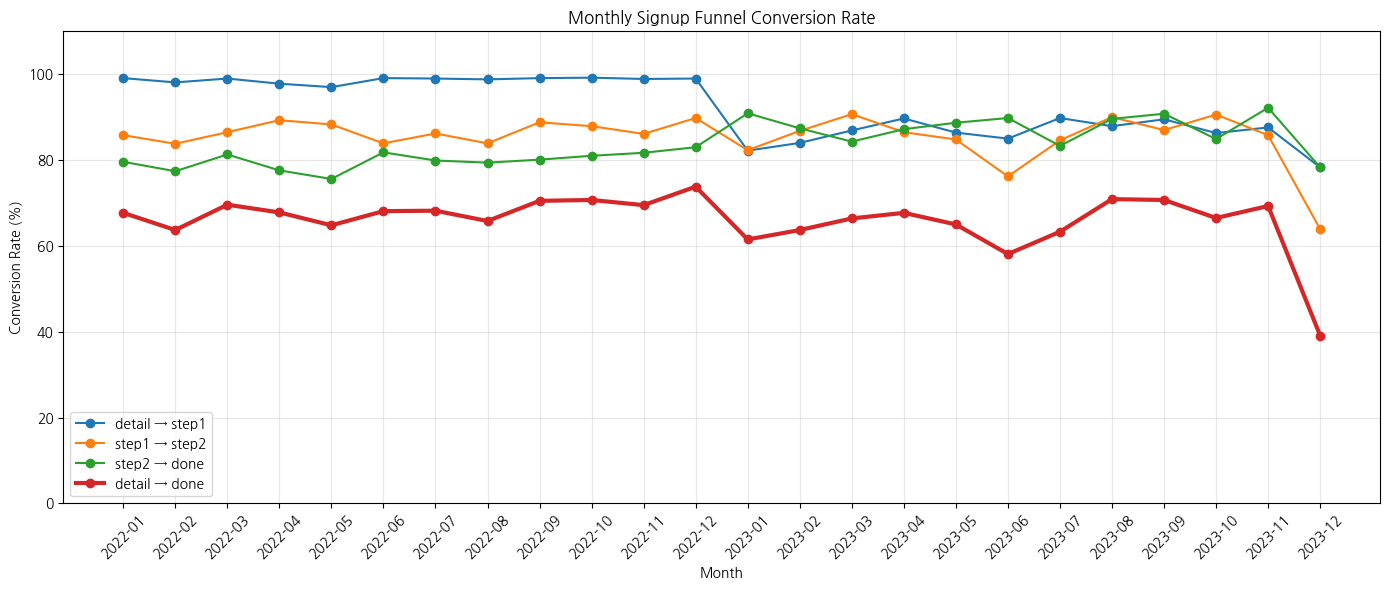

In [11]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_ratio_df['month'],
    monthly_ratio_df['detail_to_step1_rate'],
    marker='o',
    label='detail → step1'
)

plt.plot(
    monthly_ratio_df['month'],
    monthly_ratio_df['step1_to_step2_rate'],
    marker='o',
    label='step1 → step2'
)

plt.plot(
    monthly_ratio_df['month'],
    monthly_ratio_df['step2_to_done_rate'],
    marker='o',
    label='step2 → done'
)

plt.plot(
    monthly_ratio_df['month'],
    monthly_ratio_df['detail_to_done_rate'],
    marker='o',
    linewidth=3,
    label='detail → done'
)

plt.title('Monthly Signup Funnel Conversion Rate')
plt.xlabel('Month')
plt.ylabel('Conversion Rate (%)')

plt.xticks(rotation=45)
plt.ylim(0, 110)

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

### 2-4. 세부 단계별 행동 패턴 (step1~3 내부 분기)

In [12]:
query = signup_cte + """
SELECT
    -- 1. Detail 단계 (모수 1 기반)
    COUNT(DISTINCT d.user_uuid) AS detail,

    -- 2. Step 1 세부 단계 (모수 2 기반 - Detail을 거치고 Step1 권역에 들어온 로그 대상)
    COUNT(DISTINCT CASE WHEN l1.URL LIKE '%%signup/step1/name%%' THEN l1.user_uuid END) AS step1_name,
    COUNT(DISTINCT CASE WHEN l1.URL LIKE '%%signup/step1/verify%%' THEN l1.user_uuid END) AS step1_verify,

    -- 3. Step 2 세부 단계 (모수 3 기반 - Step1을 거치고 Step2 권역에 들어온 로그 대상)
    COUNT(DISTINCT CASE WHEN l2.URL LIKE '%%signup/step2/career%%' THEN l2.user_uuid END) AS step2_career,
    COUNT(DISTINCT CASE WHEN l2.URL LIKE '%%signup/step2/education%%' THEN l2.user_uuid END) AS step2_education,
    COUNT(DISTINCT CASE WHEN l2.URL LIKE '%%signup/step2/image%%' THEN l2.user_uuid END) AS step2_image,

    -- 4. Step 3 세부 단계 (Step2를 거쳐온 유저를 기준으로 삼되, 최종 'done' 성공 유저는 모수 4 활용)
    COUNT(DISTINCT CASE WHEN l3.URL LIKE '%%signup/step3/import%%' THEN l3.user_uuid END) AS step3_import,
    COUNT(DISTINCT CASE WHEN l3.URL LIKE '%%signup/step3/discover%%' THEN l3.user_uuid END) AS step3_discover,
    COUNT(DISTINCT s3.user_uuid) AS step3_done -- 원래 조건(only response_code 200)이 반영된 최종 모수 사용

FROM step_detail_users d

-- Step 1 세부 카운팅을 위한 조인 (Detail 통과 시점 이후의 Step1 로그 매칭)
LEFT JOIN logs l1
    ON d.user_uuid = l1.user_uuid
   AND l1.timestamp >= d.detail_time
   AND l1.URL LIKE '%%signup/step1%%'

-- Step 2 세부 카운팅을 위한 조인 (Step1 통과 시점 이후의 Step2 로그 매칭)
LEFT JOIN step1_users s1
    ON d.user_uuid = s1.user_uuid
LEFT JOIN logs l2
    ON s1.user_uuid = l2.user_uuid
   AND l2.timestamp >= s1.step1_time
   AND l2.URL LIKE '%%signup/step2%%'

-- Step 3 세부 카운팅을 위한 조인 (Step2 통과 시점 이후의 Step3 로그 매칭)
LEFT JOIN step2_users s2
    ON d.user_uuid = s2.user_uuid
LEFT JOIN logs l3
    ON s2.user_uuid = l3.user_uuid
   AND l3.timestamp >= s2.step2_time
   AND l3.URL LIKE '%%signup/step3%%'

-- 최종 가입 완료 모수 조인 (response_code = 200 조건 유지용)
LEFT JOIN step3_done_users s3
    ON d.user_uuid = s3.user_uuid;
"""


REFRESH = False
CACHE_FILE = "_cache/detail_signup_funnel.pkl"

if REFRESH or not os.path.exists(CACHE_FILE):
    detail_signup_df = pd.read_sql(query, engine)
    detail_signup_df.to_pickle(CACHE_FILE)
else:
    detail_signup_df = pd.read_pickle(CACHE_FILE)

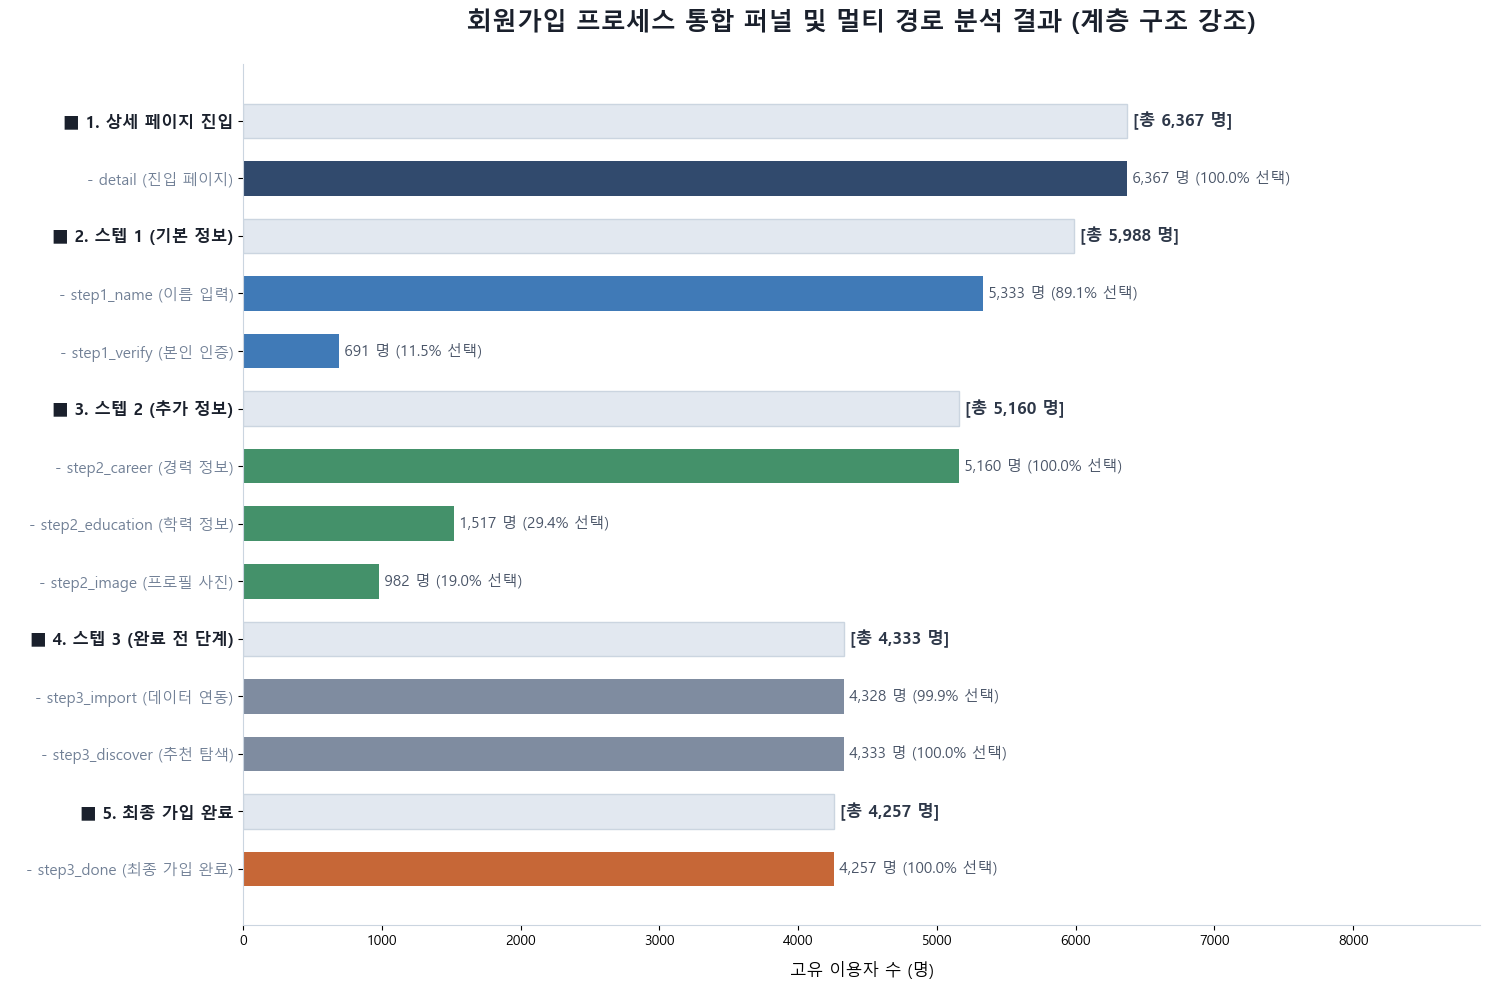

In [13]:
import platform
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==========================================
# 1. 폰트 깨짐 방지 및 메모리 초기화
# ==========================================
plt.clf()

if platform.system() == "Windows":
    plt.rc("font", family="Malgun Gothic")
elif platform.system() == "Darwin":  # Mac
    plt.rc("font", family="AppleGothic")
else:
    plt.rc("font", family="sans-serif")

plt.rcParams["axes.unicode_minus"] = False

# ==========================================
# 2. 데이터 가져오기 및 트리 구조 설정
# ==========================================
m = df.iloc[0]
s = detail_signup_df.iloc[0]

# [중요] 자식 라벨 앞에 들여쓰기("   - ")를 추가해 시각적 계층 분리
hierarchy = [
    {
        "main_label": "■ 1. 상세 페이지 진입",
        "main_val": int(m["funnel_1_detail_users"]),
        "subs": [("   - detail (진입 페이지)", int(s["detail"]))],
        "color": "#1a365d",
    },
    {
        "main_label": "■ 2. 스텝 1 (기본 정보)",
        "main_val": int(m["funnel_2_step1_users"]),
        "subs": [
            ("   - step1_name (이름 입력)", int(s["step1_name"])),
            ("   - step1_verify (본인 인증)", int(s["step1_verify"])),
        ],
        "color": "#2b6cb0",
    },
    {
        "main_label": "■ 3. 스텝 2 (추가 정보)",
        "main_val": int(m["funnel_3_step2_users"]),
        "subs": [
            ("   - step2_career (경력 정보)", int(s["step2_career"])),
            ("   - step2_education (학력 정보)", int(s["step2_education"])),
            ("   - step2_image (프로필 사진)", int(s["step2_image"])),
        ],
        "color": "#2f855a",
    },
    {
        "main_label": "■ 4. 스텝 3 (완료 전 단계)",
        "main_val": int(s["step3_discover"]),
        "subs": [
            ("   - step3_import (데이터 연동)", int(s["step3_import"])),
            ("   - step3_discover (추천 탐색)", int(s["step3_discover"])),
        ],
        "color": "#718096",
    },
    {
        "main_label": "■ 5. 최종 가입 완료",
        "main_val": int(m["funnel_4_done_users"]),
        "subs": [("   - step3_done (최종 가입 완료)", int(s["step3_done"]))],
        "color": "#c05621",
    },
]

labels = []
values = []
colors = []
annotations = []
is_parent_list = []  # 부모 여부를 체크하기 위한 리스트 추가

# 가로 차트용 정순 정렬을 위한 역순 배치
for stage in reversed(hierarchy):
    main_val = stage["main_val"]

    # 자식 노드 배치
    for sub_label, sub_val in reversed(stage["subs"]):
        labels.append(sub_label)
        values.append(sub_val)
        colors.append(stage["color"])
        is_parent_list.append(False)

        sub_ratio = (sub_val / main_val) * 100 if main_val > 0 else 0
        annotations.append(f" {sub_val:,} 명 ({sub_ratio:.1f}% 선택)")

    # 부모 노드 배치
    labels.append(stage["main_label"])
    values.append(main_val)
    colors.append("#e2e8f0")  # 부모 바 색상을 연한 배경용 회색으로 통일하여 차별화
    is_parent_list.append(True)
    annotations.append(f" [총 {main_val:,} 명]")

# ==========================================
# 3. 차트 시각화 및 스타일 가공
# ==========================================
fig, ax = plt.subplots(figsize=(15, 10))
bars = ax.barh(labels, values, color=colors, height=0.6)

# 부모 바와 자식 바의 투명도 및 주석 텍스트 스타일 커스텀 분리
for bar, ann, is_parent in zip(bars, annotations, is_parent_list):
    val = bar.get_width()

    if is_parent:
        bar.set_edgecolor("#cbd5e0")  # 부모는 투명한 박스 테두리선 부여
        bar.set_linewidth(1)
        ax.text(
            val,
            bar.get_y() + bar.get_height() / 2,
            ann,
            va="center",
            ha="left",
            fontsize=12,
            fontweight="bold",
            color="#2d3748",
        )
    else:
        # 실제 중요한 자식 데이터 바는 꽉 찬 유색으로 살림
        bar.set_alpha(0.9)
        ax.text(
            val,
            bar.get_y() + bar.get_height() / 2,
            ann,
            va="center",
            ha="left",
            fontsize=11,
            color="#4a5568",
        )

# 레이아웃 디테일 정리
ax.set_title(
    "회원가입 프로세스 통합 퍼널 및 멀티 경로 분석 결과 (계층 구조 강조)",
    fontsize=18,
    fontweight="bold",
    pad=25,
    color="#1a202c",
)
ax.set_xlabel("고유 이용자 수 (명)", fontsize=12, labelpad=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#cbd5e0")
ax.spines["bottom"].set_color("#cbd5e0")

# 우측 가독성 마진 확보
ax.set_xlim(0, int(m["funnel_1_detail_users"]) * 1.40)

# y축 항목 글자 색상 및 두께 분리
for t in ax.get_yticklabels():
    if "■" in t.get_text():
        t.set_fontsize(12)
        t.set_fontweight("bold")
        t.set_color("#1a202c")
    else:
        t.set_fontsize(11)
        t.set_color("#718096")  # 자식 글자는 회색 톤으로 살짝 낮춤

plt.tight_layout()
plt.show()

## 3. 가입 소요 시간 분석

### 3-1. detail 진입 → 가입 완료까지 리드타임 분포

In [14]:

query = """
WITH logs AS (
    SELECT user_uuid, `timestamp`, URL, response_code
    FROM log_2022
    WHERE user_uuid IS NOT NULL
      AND response_code NOT IN (400,404,500)

    UNION ALL

    SELECT user_uuid, `timestamp`, URL, response_code
    FROM log_2023
    WHERE user_uuid IS NOT NULL
      AND response_code NOT IN (400,404,500)
),

detail_users AS (
    SELECT
        user_uuid,
        MIN(`timestamp`) AS detail_time
    FROM logs
    WHERE URL LIKE '%%signup/detail%%'
    GROUP BY user_uuid
),

step1_users AS (
    SELECT
        d.user_uuid,
        d.detail_time,
        MIN(l.`timestamp`) AS step1_time
    FROM detail_users d
    JOIN logs l
      ON d.user_uuid = l.user_uuid
     AND l.`timestamp` >= d.detail_time
    WHERE l.URL LIKE '%%signup/step1%%'
    GROUP BY d.user_uuid, d.detail_time
),

step2_users AS (
    SELECT
        s1.user_uuid,
        s1.detail_time,
        MIN(l.`timestamp`) AS step2_time
    FROM step1_users s1
    JOIN logs l
      ON s1.user_uuid = l.user_uuid
     AND l.`timestamp` >= s1.step1_time
    WHERE l.URL LIKE '%%signup/step2%%'
    GROUP BY s1.user_uuid, s1.detail_time
),

signup_done_users AS (
    SELECT
        s2.user_uuid,
        s2.detail_time,
        MIN(l.`timestamp`) AS done_time
    FROM step2_users s2
    JOIN logs l
      ON s2.user_uuid = l.user_uuid
     AND l.`timestamp` >= s2.step2_time
    WHERE l.URL LIKE '%%signup/step3/done%%'
      AND l.response_code = 200
    GROUP BY s2.user_uuid, s2.detail_time
)

SELECT
    user_uuid,
    detail_time,
    done_time,
    TIMESTAMPDIFF(SECOND, detail_time, done_time) AS signup_seconds,
    ROUND(TIMESTAMPDIFF(SECOND, detail_time, done_time) / 60, 2) AS signup_minutes
FROM signup_done_users
ORDER BY signup_seconds
"""

signup_time_df = pd.read_sql(query, engine)
# (데이터 보호: 원본 미리보기 출력 제거)
# signup_time_df


In [15]:
query = """
WITH logs AS (
    SELECT user_uuid, `timestamp`, URL, response_code
    FROM log_2022
    WHERE user_uuid IS NOT NULL
      AND response_code NOT IN (400,404,500)

    UNION ALL

    SELECT user_uuid, `timestamp`, URL, response_code
    FROM log_2023
    WHERE user_uuid IS NOT NULL
      AND response_code NOT IN (400,404,500)
),

detail_users AS (
    SELECT
        user_uuid,
        MIN(`timestamp`) AS detail_time
    FROM logs
    WHERE URL LIKE '%%signup/detail%%'
    GROUP BY user_uuid
),

step1_users AS (
    SELECT
        d.user_uuid,
        d.detail_time,
        MIN(l.`timestamp`) AS step1_time
    FROM detail_users d
    JOIN logs l
      ON d.user_uuid = l.user_uuid
     AND l.`timestamp` >= d.detail_time
    WHERE l.URL LIKE '%%signup/step1%%'
    GROUP BY d.user_uuid, d.detail_time
),

step2_users AS (
    SELECT
        s1.user_uuid,
        s1.detail_time,
        MIN(l.`timestamp`) AS step2_time
    FROM step1_users s1
    JOIN logs l
      ON s1.user_uuid = l.user_uuid
     AND l.`timestamp` >= s1.step1_time
    WHERE l.URL LIKE '%%signup/step2%%'
    GROUP BY s1.user_uuid, s1.detail_time
),

signup_done_users AS (
    SELECT
        s2.user_uuid,
        s2.detail_time,
        MIN(l.`timestamp`) AS done_time
    FROM step2_users s2
    JOIN logs l
      ON s2.user_uuid = l.user_uuid
     AND l.`timestamp` >= s2.step2_time
    WHERE l.URL LIKE '%%signup/step3/done%%'
      AND l.response_code = 200
    GROUP BY s2.user_uuid, s2.detail_time
)

SELECT
    COUNT(*) AS signup_users,
    ROUND(AVG(TIMESTAMPDIFF(SECOND, detail_time, done_time)) / 86400, 2) AS avg_days,
    ROUND(MIN(TIMESTAMPDIFF(SECOND, detail_time, done_time)) / 86400, 2) AS min_days,
    ROUND(MAX(TIMESTAMPDIFF(SECOND, detail_time, done_time)) / 86400, 2) AS max_days
FROM signup_done_users
"""

signup_time_summary_df = pd.read_sql(query, engine)
signup_time_summary_df

- 평균 가입 시간 : 3.1일
    - 단계를 바로 이행하지 않고, 중간 이탈 및 재방문해 다시 이행으로 판단
- 이상치 671일 미쳤네

### 3-2. 중앙값 vs 평균의 괴리 해석 (이상치 영향)

In [16]:
# 중앙값
signup_time_df['signup_days'] = (
    signup_time_df['signup_seconds'] / 86400
)

signup_time_df['signup_days'].median()

- 중앙값 : 초단위로 환산 시, 2분 16초
- 가입완료 유저의 절반은 온보딩 진입 후 2분 16초 이내에 가입 완료

- 즉, 대부분은 빠르게 가입하나 일부 유저의 가입 완료일수가 평균을 크게 끌어올린 케이스

In [17]:
# 단위별 파악
signup_time_df['signup_days'].quantile([0.5, 0.75, 0.9, 0.95, 0.99])

- 분으로 환산 시,
    - 50 % : 2.27분
    - 75% : 3.63분
    - 90% : 7.28분
    - 95% : 18.16분
    - 99% : 61.8일
- 대부분 가입 완료 유저는 온보딩 진입 후 10분 이내 가입 완료함

### 3-3. 최초 서비스 유입 기준 리드타임 분석

In [18]:
query = """WITH logs AS (
    SELECT user_uuid, timestamp, URL, response_code
    FROM log_2022
    WHERE user_uuid IS NOT NULL
      AND response_code NOT IN (400, 404, 500)

    UNION ALL

    SELECT user_uuid, timestamp, URL, response_code
    FROM log_2023
    WHERE user_uuid IS NOT NULL
      AND response_code NOT IN (400, 404, 500)
),

-- [이전 단계 복기용 퍼널 구조 유지]
step_detail_users AS (
    SELECT user_uuid, MIN(timestamp) AS detail_time
    FROM logs
    WHERE URL LIKE '%%signup/detail%%'
    GROUP BY user_uuid
),

step1_users AS (
    SELECT l.user_uuid, MIN(l.timestamp) AS step1_time
    FROM logs l
    INNER JOIN step_detail_users d ON l.user_uuid = d.user_uuid AND l.timestamp >= d.detail_time
    WHERE l.URL LIKE '%%signup/step1%%'
    GROUP BY l.user_uuid
),

step2_users AS (
    SELECT l.user_uuid, MIN(l.timestamp) AS step2_time
    FROM logs l
    INNER JOIN step1_users s1 ON l.user_uuid = s1.user_uuid AND l.timestamp >= s1.step1_time
    WHERE l.URL LIKE '%%signup/step2%%'
    GROUP BY l.user_uuid
),

-- [1] ★ 새로운 기준 모수: 최종 가입 완료를 성공(200)한 유저 및 완료 시간 산정
step3_done_users AS (
    SELECT
        l.user_uuid,
        MIN(l.timestamp) AS done_time
    FROM logs l
    INNER JOIN step2_users s2 
        ON l.user_uuid = s2.user_uuid
       AND l.timestamp >= s2.step2_time
    WHERE l.URL LIKE '%%signup/step3/done%%'
      AND l.response_code = 200
    GROUP BY l.user_uuid
),

-- [2] 각 유저가 전체 로그 통틀어 가장 처음 발생시킨 '평생 최초 로그 시간' 산정
user_first_logs AS (
    SELECT
        user_uuid,
        MIN(timestamp) AS first_login_time
    FROM logs
    GROUP BY user_uuid
)

-- [3] 최종 완료 유저 기준 조인 및 시간 차이(초 단위, 일 단위) 계산
SELECT
    s3.user_uuid,
    f.first_login_time AS system_first_time,   -- 서비스 전체에서 처음 포착된 시간
    s3.done_time AS signup_done_time,           -- 회원가입 완료(step3/done) 시간
    
    -- 초(Second) 단위 차이 계산
    TIMESTAMPDIFF(SECOND, f.first_login_time, s3.done_time) AS lead_time_seconds,
    
    -- 일(Day) 단위 차이 계산 (당일 완료는 0일)
    TIMESTAMPDIFF(DAY, f.first_login_time, s3.done_time) AS lead_time_days
FROM step3_done_users s3
INNER JOIN user_first_logs f 
    ON s3.user_uuid = f.user_uuid
ORDER BY lead_time_seconds DESC;
"""

REFRESH = False
CACHE_FILE = "_cache/signup_lead_time.pkl"

if REFRESH or not os.path.exists(CACHE_FILE):
    signup_leadtime = pd.read_sql(query, engine)
    signup_leadtime.to_pickle(CACHE_FILE)
else:
    signup_leadtime = pd.read_pickle(CACHE_FILE)

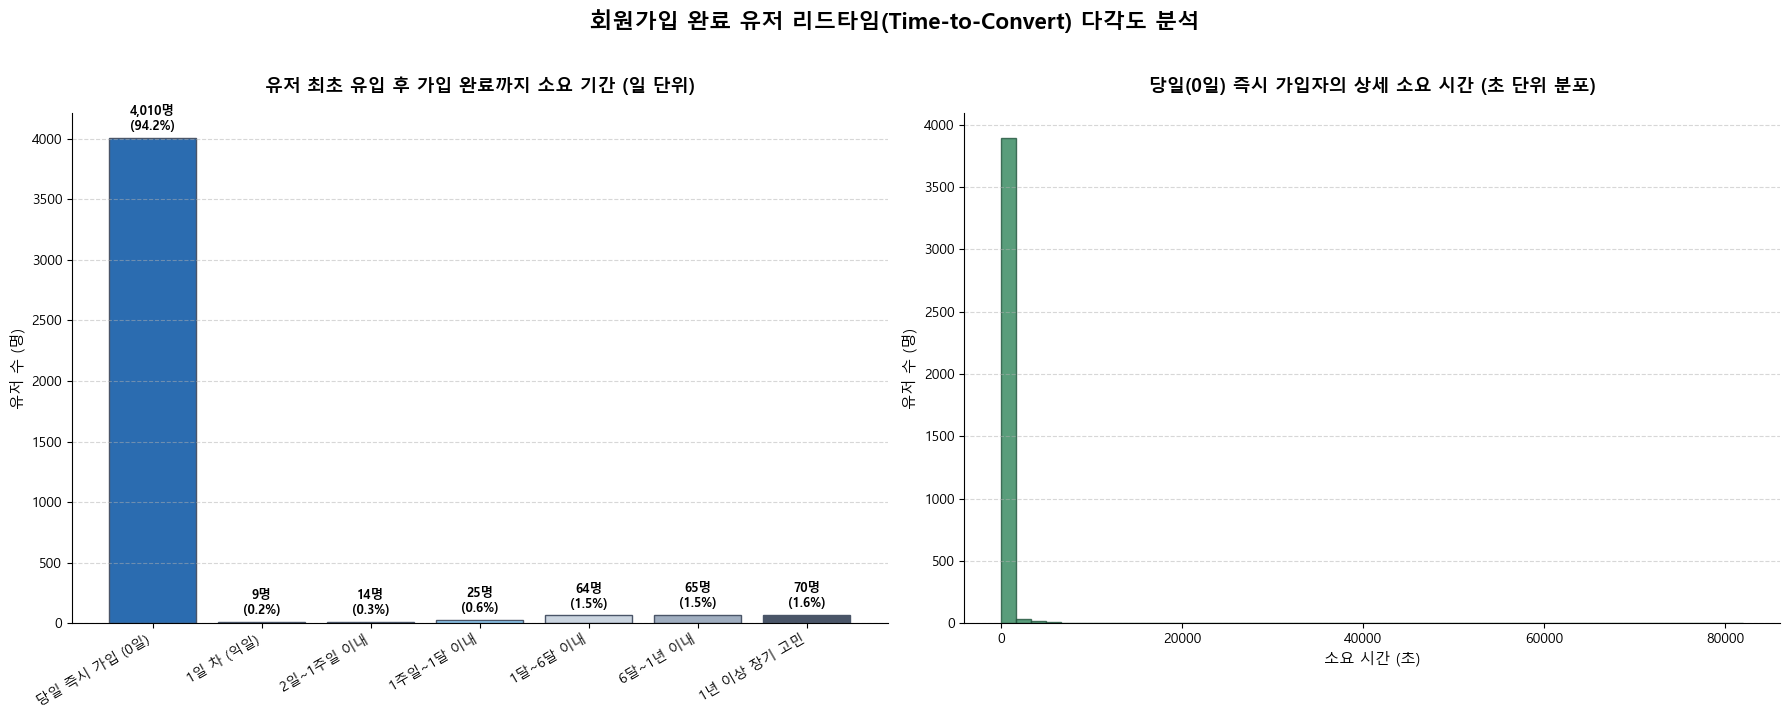

In [19]:
# ==========================================
# 1. 폰트 및 스타일 초기화
# ==========================================
plt.clf()
if platform.system() == "Windows":
    plt.rc("font", family="Malgun Gothic")
elif platform.system() == "Darwin":  # Mac
    plt.rc("font", family="AppleGothic")
plt.rcParams["axes.unicode_minus"] = False

# ==========================================
# 2. 데이터 가공 (구간별 코호트 정의)
# ==========================================
# signup_leadtime 데이터프레임을 복사해서 사용합니다.
df_clean = signup_leadtime.copy()

# 일(Day) 기준 구간 나누기 기획
bins = [-1, 0, 1, 7, 30, 180, 360, float("inf")]
labels = [
    "당일 즉시 가입 (0일)",
    "1일 차 (익일)",
    "2일~1주일 이내",
    "1주일~1달 이내",
    "1달~6달 이내",
    "6달~1년 이내",
    "1년 이상 장기 고민",
]

df_clean["lead_time_group"] = pd.cut(
    df_clean["lead_time_days"], bins=bins, labels=labels
)
group_counts = df_clean["lead_time_group"].value_counts().reindex(labels)
group_pct = (group_counts / len(df_clean)) * 100

# 당일(0일) 가입자 중 초(Second) 단위 분기 추출
day0_seconds = df_clean[df_clean["lead_time_days"] == 0]["lead_time_seconds"]

# ==========================================
# 3. 1행 2열 서브플롯 시각화
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- [왼쪽 차트: 일 단위 리드타임 구간 분포] ---
colors = [
    "#2b6cb0",
    "#4299e1",
    "#63b3ed",
    "#90cdf4",
    "#cbd5e0",
    "#a0aec0",
    "#4a5568",
]
bars = axes[0].bar(
    group_counts.index, group_counts.values, color=colors, edgecolor="#4a5568"
)

axes[0].set_title(
    "유저 최초 유입 후 가입 완료까지 소요 기간 (일 단위)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
axes[0].set_ylabel("유저 수 (명)", fontsize=11)
axes[0].set_xticklabels(group_counts.index, rotation=30, ha="right", fontsize=10)

# 막대 위에 값 및 퍼센트 표시
for bar in bars:
    height = bar.get_height()
    if height > 0:
        pct = (height / len(df_clean)) * 100
        axes[0].text(
            bar.get_x() + bar.get_width() / 2.0,
            height + (max(group_counts.values) * 0.01),
            f"{height:,}명\n({pct:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
        )

# --- [오른쪽 차트: 당일 가입자의 초 단위 히스토그램] ---
# 유저가 켜자마자 얼마나 빨리 가입 절차를 밟았는지 조명
axes[1].hist(
    day0_seconds, bins=50, color="#2f855a", edgecolor="#22543d", alpha=0.8
)
axes[1].set_title(
    "당일(0일) 즉시 가입자의 상세 소요 시간 (초 단위 분포)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
axes[1].set_xlabel("소요 시간 (초)", fontsize=11)
axes[1].set_ylabel("유저 수 (명)", fontsize=11)

# 테두리 및 그리드 정리
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

# 상단 큰 제목 추가
plt.suptitle(
    "회원가입 완료 유저 리드타임(Time-to-Convert) 다각도 분석",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

## 4. 유입 경로 분석

In [20]:
query = """
    WITH user_signup_time AS (
        -- [1] 각 유저별로 최종 가입 완료(step3/done)를 성공한 '최초 시간'을 구합니다.
        SELECT 
            user_uuid,
            MIN(timestamp) AS signup_done_time
        FROM (
            SELECT user_uuid, timestamp, URL, response_code FROM log_2022
            UNION ALL
            SELECT user_uuid, timestamp, URL, response_code FROM log_2023
        ) AS sub
        WHERE URL LIKE '%%signup/step3/done%%'
        AND response_code = 200
        AND user_uuid IS NOT NULL
        GROUP BY user_uuid
    ),

    all_logs AS (
        -- [2] 전체 로그를 하나로 합칩니다.
        SELECT user_uuid, timestamp, URL FROM log_2022
        UNION ALL
        SELECT user_uuid, timestamp, URL FROM log_2023
    )

    -- [3] 최종 조인 및 필터링
    SELECT 
        l.user_uuid,
        l.timestamp AS utm_visit_time,
        u.signup_done_time,
        l.URL AS utm_url
    FROM all_logs l
    INNER JOIN user_signup_time u ON l.user_uuid = u.user_uuid
    WHERE l.timestamp < u.signup_done_time  
    AND l.URL LIKE '%%utm_%%'             
    ORDER BY l.user_uuid, l.timestamp;
"""

utm_df = pd.read_sql(query, engine)
# (데이터 보호: 원본 미리보기 출력 제거)
# utm_df


### 4-1. UTM별 기여도 및 도달 페이지 유형 분석

In [21]:
import pandas as pd
from urllib.parse import parse_qs, urlparse

# ========================================================
# [1] 복잡한 URL 주소에서 핵심 UTM 정보만 쏙쏙 추출하는 함수
# ========================================================
def extract_utm(url):
    try:
        # URL 분석을 위해 쪼개기
        parsed = urlparse(url)
        params = parse_qs(parsed.query)

        # 파라미터가 비어있으면 뒤쪽 텍스트를 직접 파싱 (도메인이 없는 특수 주소 대응)
        if not params and "?" in url:
            query_str = url.split("?")[-1]
            params = parse_qs(query_str)

        # 각 utm 값이 있으면 가져오기 (없으면 'unknown')
        source = params.get("utm_source", ["unknown"])[0]
        medium = params.get("utm_medium", ["unknown"])[0]
        campaign = params.get("utm_campaign", ["unknown"])[0]

        # 유저가 도달한 순수 페이지 주소 (맨 앞 주소)
        base_page = url.split("?")[0] if "?" in url else url

        # 가독성을 위해 대표적인 페이지 유형 묶기
        if "jobs" in base_page:
            page_type = "채용 공고 페이지"
        elif "companies" in base_page:
            page_type = "기업 정보 페이지"
        elif "verify" in base_page:
            page_type = "이메일/인증 확인 페이지"
        elif "setting" in base_page:
            page_type = "설정 페이지"
        else:
            page_type = "기타 서비스 페이지"

        return pd.Series([source, medium, campaign, page_type])
    except:
        return pd.Series(["error", "error", "error", "error"])


utm_df[["source", "medium", "campaign", "page_type"]] = utm_df["utm_url"].apply(
    extract_utm
)


print("\n" + "=" * 60 + "\n")
print("=== 1. [중복제거] 어떤 채널(Source)로 '가장 많은 유저'가 유입되었을까? ===")
# 유저(user_uuid)를 중복 없이 카운트합니다.
print(utm_df.groupby("source")["user_uuid"].nunique().sort_values(ascending=False).head(10))
print("\n" + "=" * 60 + "\n")

print("=== 2. [중복제거] 어떤 매체(Medium)를 통해 가장 많은 유저가 유입되었을까? ===")
print(utm_df.groupby("medium")["user_uuid"].nunique().sort_values(ascending=False).head(10))
print("\n" + "=" * 60 + "\n")

print("=== 3. [중복제거] 유저들이 가입 직전 최초/최종적으로 도달한 웹페이지 종류는? ===")
print(utm_df.groupby("page_type")["user_uuid"].nunique().sort_values(ascending=False))



=== 1. [중복제거] 어떤 채널(Source)로 '가장 많은 유저'가 유입되었을까? ===
source
notification         542
google_jobs_apply     25
excel                  1
unknown                1
Name: user_uuid, dtype: int64


=== 2. [중복제거] 어떤 매체(Medium)를 통해 가장 많은 유저가 유입되었을까? ===
medium
email      535
organic     25
unknown     16
alink        1
Name: user_uuid, dtype: int64


=== 3. [중복제거] 유저들이 가입 직전 최초/최종적으로 도달한 웹페이지 종류는? ===
page_type
이메일/인증 확인 페이지    465
기타 서비스 페이지        69
채용 공고 페이지         66
기업 정보 페이지         39
설정 페이지            16
Name: user_uuid, dtype: int64


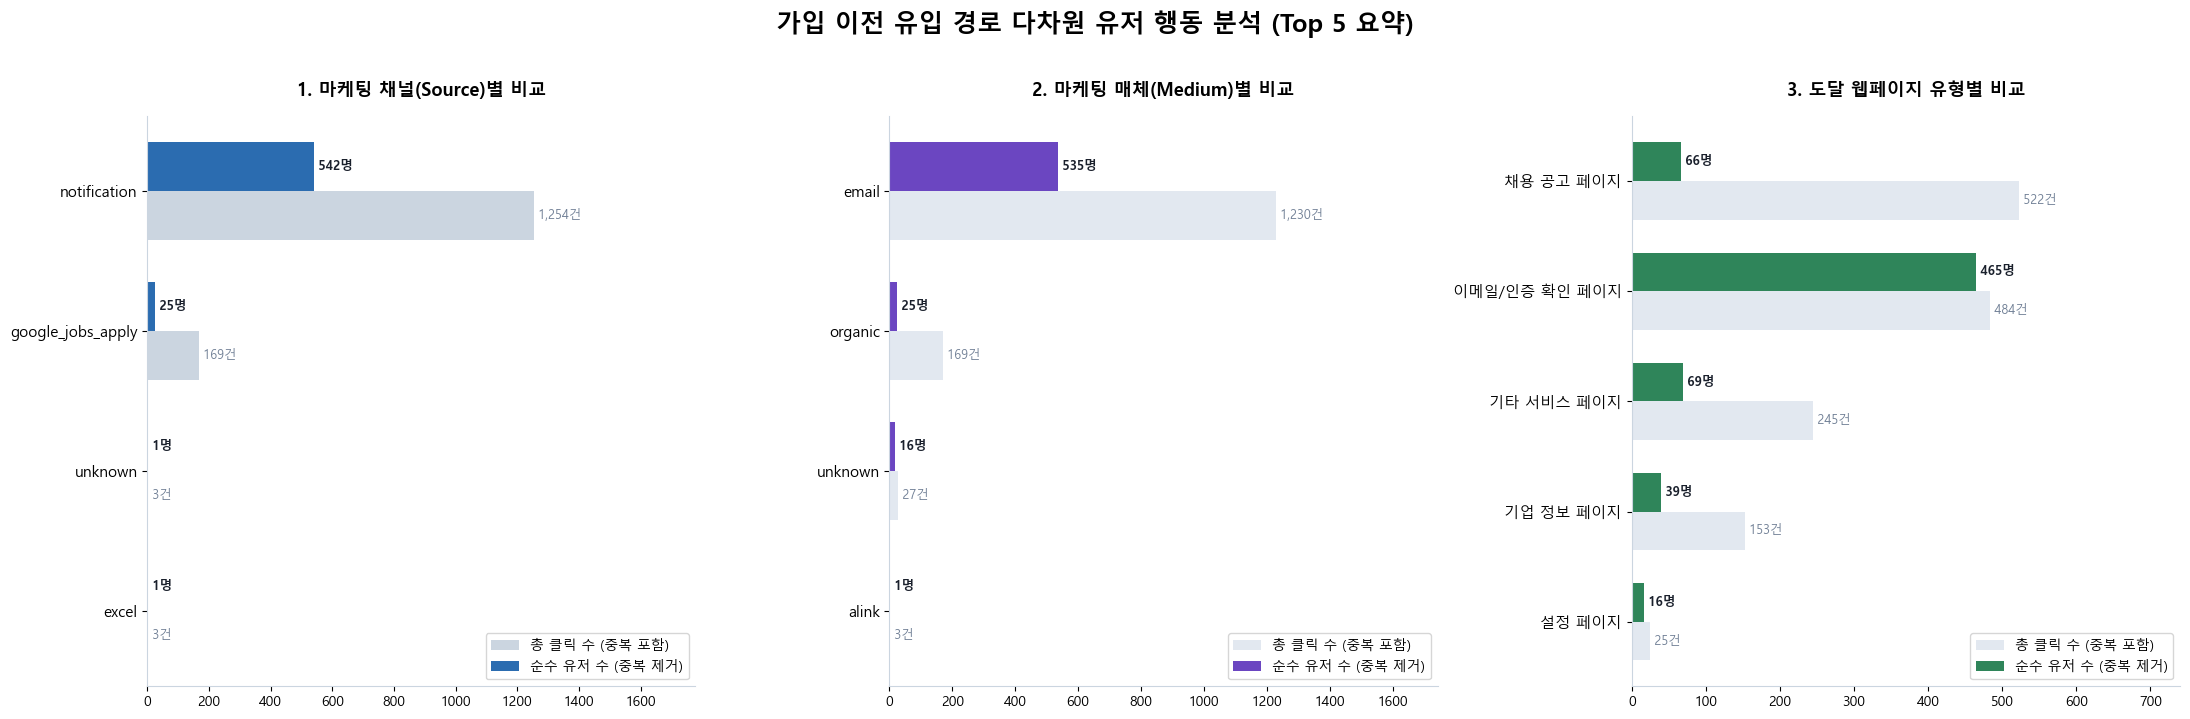

In [22]:
import platform
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==========================================
# 1. 폰트 및 스타일 초기화
# ==========================================
plt.clf()
if platform.system() == "Windows":
    plt.rc("font", family="Malgun Gothic")
elif platform.system() == "Darwin":  # Mac
    plt.rc("font", family="AppleGothic")
plt.rcParams["axes.unicode_minus"] = False

# ==========================================
# 2. 세 가지 핵심 지표 데이터 집계 (Top 5 컷팅)
# ==========================================
# 1) 마케팅 채널 (Source)
source_click = utm_df["source"].value_counts().head(5)
source_user = utm_df.groupby("source")["user_uuid"].nunique().loc[source_click.index]

# 2) 마케팅 매체 (Medium)
medium_click = utm_df["medium"].value_counts().head(5)
medium_user = utm_df.groupby("medium")["user_uuid"].nunique().loc[medium_click.index]

# 3) 웹페이지 유형 (Page Type)
page_click = utm_df["page_type"].value_counts().head(5)
page_user = utm_df.groupby("page_type")["user_uuid"].nunique().loc[page_click.index]

# ==========================================
# 3. 1행 3열 (가로 3분할) 서브플롯 생성
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(22, 7))  # 화면이 넓게 보이도록 가로 크기를 22로 확대
height = 0.35

# ------------------------------------------
# AX 1: 마케팅 채널 (Source) - 블루 계열
# ------------------------------------------
y_idx_s = np.arange(len(source_click.index))
axes[0].barh(y_idx_s + height / 2, source_click.values, height, label="총 클릭 수 (중복 포함)", color="#cbd5e0")
axes[0].barh(y_idx_s - height / 2, source_user.values, height, label="순수 유저 수 (중복 제거)", color="#2b6cb0")

axes[0].set_title("1. 마케팅 채널(Source)별 비교", fontsize=13, fontweight="bold", pad=15)
axes[0].set_yticks(y_idx_s)
axes[0].set_yticklabels(source_click.index, fontsize=11)
axes[0].legend(loc="lower right", fontsize=10)
axes[0].invert_yaxis()

for i, (c_val, u_val) in enumerate(zip(source_click.values, source_user.values)):
    axes[0].text(c_val, i + height / 2, f" {c_val:,}건", va="center", fontsize=9, color="#718096")
    axes[0].text(u_val, i - height / 2, f" {u_val:,}명", va="center", fontsize=9, fontweight="bold", color="#1a202c")

# ------------------------------------------
# AX 2: 마케팅 매체 (Medium) - 퍼플 계열 (신설 ✨)
# ------------------------------------------
y_idx_m = np.arange(len(medium_click.index))
axes[1].barh(y_idx_m + height / 2, medium_click.values, height, label="총 클릭 수 (중복 포함)", color="#e2e8f0")
axes[1].barh(y_idx_m - height / 2, medium_user.values, height, label="순수 유저 수 (중복 제거)", color="#6b46c1")  # 보라색 강조

axes[1].set_title("2. 마케팅 매체(Medium)별 비교", fontsize=13, fontweight="bold", pad=15)
axes[1].set_yticks(y_idx_m)
axes[1].set_yticklabels(medium_click.index, fontsize=11)
axes[1].legend(loc="lower right", fontsize=10)
axes[1].invert_yaxis()

for i, (c_val, u_val) in enumerate(zip(medium_click.values, medium_user.values)):
    axes[1].text(c_val, i + height / 2, f" {c_val:,}건", va="center", fontsize=9, color="#718096")
    axes[1].text(u_val, i - height / 2, f" {u_val:,}명", va="center", fontsize=9, fontweight="bold", color="#1a202c")

# ------------------------------------------
# AX 3: 웹페이지 유형 (Page Type) - 그린 계열
# ------------------------------------------
y_idx_p = np.arange(len(page_click.index))
axes[2].barh(y_idx_p + height / 2, page_click.values, height, label="총 클릭 수 (중복 포함)", color="#e2e8f0")
axes[2].barh(y_idx_p - height / 2, page_user.values, height, label="순수 유저 수 (중복 제거)", color="#2f855a")

axes[2].set_title("3. 도달 웹페이지 유형별 비교", fontsize=13, fontweight="bold", pad=15)
axes[2].set_yticks(y_idx_p)
axes[2].set_yticklabels(page_click.index, fontsize=11)
axes[2].legend(loc="lower right", fontsize=10)
axes[2].invert_yaxis()

for i, (c_val, u_val) in enumerate(zip(page_click.values, page_user.values)):
    axes[2].text(c_val, i + height / 2, f" {c_val:,}건", va="center", fontsize=9, color="#718096")
    axes[2].text(u_val, i - height / 2, f" {u_val:,}명", va="center", fontsize=9, fontweight="bold", color="#1a202c")

# ==========================================
# 4. 차트 디테일 테두리 정리 및 레이아웃 다듬기
# ==========================================
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cbd5e0")
    ax.spines["bottom"].set_color("#cbd5e0")
    # 텍스트 라벨이 우측으로 밀려 잘리지 않도록 x축 여백을 최대값 기준 35% 추가 확보
    current_xlim = ax.get_xlim()
    ax.set_xlim(0, current_xlim[1] * 1.35)

plt.suptitle("가입 이전 유입 경로 다차원 유저 행동 분석 (Top 5 요약)", fontsize=18, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

#### 1. 종합 요약
* **CRM 마케팅의 압도적 기여:** 가입 완료 유저의 대부분이 자체 알림(`notification`)과 이메일(`email`) 매체를 통해 유입됨
* **목적형 유입과 탐색형 유입의 공존:** 이메일 인증 확인을 위한 필수 진입과 더불어, 채용 공고를 직접 조회하며 가입으로 전환되는 행동 패턴이 뚜렷하게 관찰됨

---

#### 2. 축별 핵심 분석

##### [마케팅 채널 & 매체] 인하우스 CRM 메일의 중심성
* **현황:** 채널 기준 `notification` 1,254건(542명), 매체 기준 `email` 1,230건(535명)으로 압도적 1위 기록
* **해석:** 외부 광고(`google_jobs_apply`, 25명) 대비 자체 이메일 알림을 통한 유입 및 가입 전환 성과가 가장 강력함. 다만 유저 1명당 평균 2.3회 클릭 후 가입하는 경향을 보여, 메일을 열어본 뒤 최종 완료까지 일정 수준의 탐색 기간이나 반복 고민 주기가 존재함

##### [도달 웹페이지] 유저의 가입 목적 분기
* **현황:** 이메일/인증 확인 페이지 484건(465명), 채용 공고 페이지 522건(66명)
* **해석:** 유입 패턴이 두 갈래로 나뉘었음. '이메일/인증 확인'은 유저당 클릭 수가 1회에 수렴(484건/465명)하여 가입 목적을 즉시 달성하는 정직한 흐름을 보임. 반면 '채용 공고 페이지'는 고작 66명의 순수 유저가 522건의 조회수를 발생시켜, 매력적인 공고를 수차례 반복 탐색하다가 최종 가입을 결심하는 강력한 '미끼 상품' 역할을 하고 있음
---

#### 3. 핵심 제언 (Action Items)

1. **CRM 이메일 가독성 및 여정 최적화:** 현재 가입 성공의 가장 큰 파이프라인이 이메일(`email`)이므로, 메일 내 UI/UX 리뉴얼 및 개인화 추천 공고 정밀화를 통해 유저 1인당 발생하는 반복 클릭 피로도(평균 2.3회)를 낮추고 즉시 전환을 유도할 것
2. **채용 공고 기반의 가입 랜딩 설계:** '채용 공고 페이지'가 소수 유저에게 매우 높은 고반복 조회를 이끌어내는 핵심 트리거이므로, 비회원이 공고를 조회할 때 가입 팝업이나 허들을 세련되게 배치하여 탐색형 유저의 회원 전환 프로세스를 가속화할 것

## 5. 시계열 패턴 분석

In [23]:
query = """WITH logs AS (
    SELECT user_uuid, timestamp, URL, response_code
    FROM log_2022
    WHERE user_uuid IS NOT NULL
      AND response_code NOT IN (400, 404, 500)

    UNION ALL

    SELECT user_uuid, timestamp, URL, response_code
    FROM log_2023
    WHERE user_uuid IS NOT NULL
      AND response_code NOT IN (400, 404, 500)
),

-- 이전 퍼널들의 의존성 관계(선행 조건)를 만족하며 최종 가입을 완료한 유저 식별
step_detail_users AS (
    SELECT user_uuid, MIN(timestamp) AS detail_time
    FROM logs
    WHERE URL LIKE '%%signup/detail%%'
    GROUP BY user_uuid
),

step1_users AS (
    SELECT l.user_uuid, MIN(l.timestamp) AS step1_time
    FROM logs l
    INNER JOIN step_detail_users d ON l.user_uuid = d.user_uuid AND l.timestamp >= d.detail_time
    WHERE l.URL LIKE '%%signup/step1%%'
    GROUP BY l.user_uuid
),

step2_users AS (
    SELECT l.user_uuid, MIN(l.timestamp) AS step2_time
    FROM logs l
    INNER JOIN step1_users s1 ON l.user_uuid = s1.user_uuid AND l.timestamp >= s1.step1_time
    WHERE l.URL LIKE '%%signup/step2%%'
    GROUP BY l.user_uuid
)

-- ★ 최종 가입 성공(200 OK) 데이터만 명확하게 추출
SELECT
    l.user_uuid,
    MIN(l.timestamp) AS signup_done_time, -- 최초 가입 완료 시점
    'signup/step3/done' AS URL
FROM logs l
INNER JOIN step2_users s2 
    ON l.user_uuid = s2.user_uuid
   AND l.timestamp >= s2.step2_time
WHERE l.URL LIKE '%%signup/step3/done%%'
  AND l.response_code = 200
GROUP BY l.user_uuid
ORDER BY signup_done_time ASC;
"""

signup_done_df = pd.read_sql(query, engine)
# (데이터 보호: 원본 미리보기 출력 제거)
# signup_done_df


### 5-1. 월별 가입 완료 추이 (2022~2023 장기 추세)

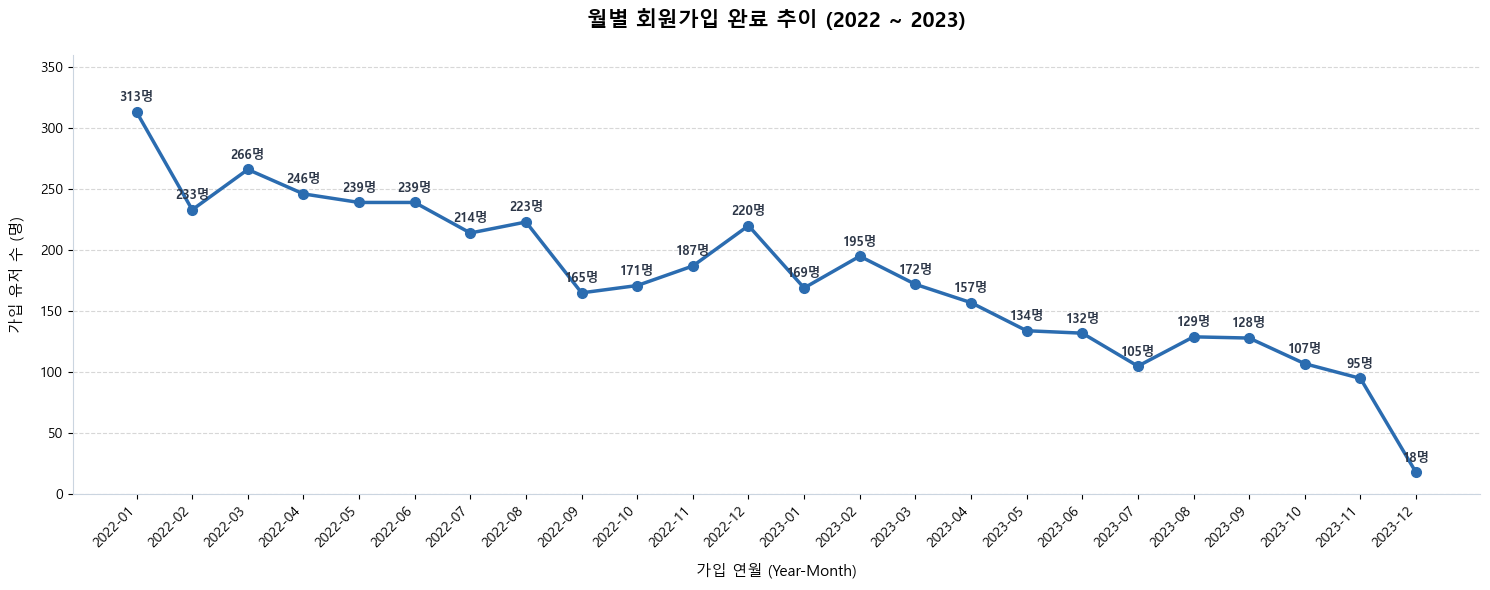

In [24]:
# 데이터프레임 준비
df_done = signup_done_df.copy() if "signup_done_df" in locals() else df_clean.copy()

# ==========================================
# 1. 폰트 및 스타일 초기화
# ==========================================
plt.clf()
if platform.system() == "Windows":
    plt.rc("font", family="Malgun Gothic")
elif platform.system() == "Darwin":  # Mac
    plt.rc("font", family="AppleGothic")
plt.rcParams["axes.unicode_minus"] = False

# ==========================================
# 2. 시계열 데이터 가공 (연-월 변환 및 집계)
# ==========================================
# 문자열인 시각 데이터를 datetime 형태로 변환
df_done["signup_done_time"] = pd.to_datetime(df_done["signup_done_time"])

# 'YYYY-MM' 형태로 월별 텍스트 추출
df_done["signup_month"] = df_done["signup_done_time"].dt.to_period("M")

# 월별 고유 유저 수 카운트 및 정렬
monthly_trend = (
    df_done.groupby("signup_month")["user_uuid"].nunique().sort_index()
)

# 그래프 X축 표시를 위해 문자열로 다시 변환
monthly_trend.index = monthly_trend.index.astype(str)

# ==========================================
# 3. 꺾은선 그래프(Line Chart) 시각화
# ==========================================
plt.figure(figsize=(15, 6))

# 메인 트렌드 선 그리기
plt.plot(
    monthly_trend.index,
    monthly_trend.values,
    marker="o",
    color="#2b6cb0",
    linewidth=2.5,
    markersize=7,
    label="가입 완료 유저 수",
)

# 그래프 타이틀 및 축 라벨 설정
plt.title(
    "월별 회원가입 완료 추이 (2022 ~ 2023)",
    fontsize=15,
    fontweight="bold",
    pad=20,
)
plt.xlabel("가입 연월 (Year-Month)", fontsize=11, labelpad=10)
plt.ylabel("가입 유저 수 (명)", fontsize=11, labelpad=10)

# X축 텍스트 45도 회전하여 겹침 방지
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)

# 데이터 포인트마다 수치 라벨링 표시
for i, val in enumerate(monthly_trend.values):
    plt.text(
        i,
        val + (max(monthly_trend.values) * 0.02),
        f"{val:,}명",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="#2d3748",
    )

# 레이아웃 테두리 및 그리드 다듬기
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#cbd5e0")
ax.spines["bottom"].set_color("#cbd5e0")
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Y축 여백을 상단으로 15% 더 확보하여 라벨이 안 가려지게 조정
plt.ylim(0, max(monthly_trend.values) * 1.15)

plt.tight_layout()
plt.show()

### 해석

- 퍼널별 변동간 큰 차이 없이 일률적으로 감소 -> 가입 시도하는 유저 자체가 감소중
    - 2022년 12월 :  298  295  265  220 
    - 2023년 12월  : 46   36   23   18
    - 1년 사이에 가입 시도 유저 84%, 가입완료 유저 92% 감소
    - 특히 2023년 12월의 경우 표본 자체가 적어 해석에 주의를 요함



In [25]:
# detail -> done 이탈율 순위
monthly_ratio_df.sort_values('detail_to_done_rate')

#### 해석

- 2023년 이후 전체 유저수는 감소했으나, 후기 전환율은 오히려 상승하는 모습을 보임
    - 가입 의사 높은 유저의 유입비중 증가 가능성
    - 서비스가 집중하고 있는 특정 카테고리 중심으로 유저품질 상승 가능성 
- 전체 전환율(빨강, detail -> done)은 비교적 안정적이다가 2022년 12월, 2023년 5월, 2023년 12월에 큰 하락을 보임
    - 채용시즌에 영향받았을 가능성
- 2023년 1월 초기 전환율(파랑) 급감
    - 그러나 후기 전환율(초록) 구간은 상승
    - 회원가입 초반의 이슈를 찾아야 할 필요가 있음
- 전반적으로 후기 전환율(초록) 구간의 병목이 컸으나 일부 구간에서 중기 전환율(노랑) 구간의 병목이 상대적으로 상승

### 5-2. 요일별 가입 집중도

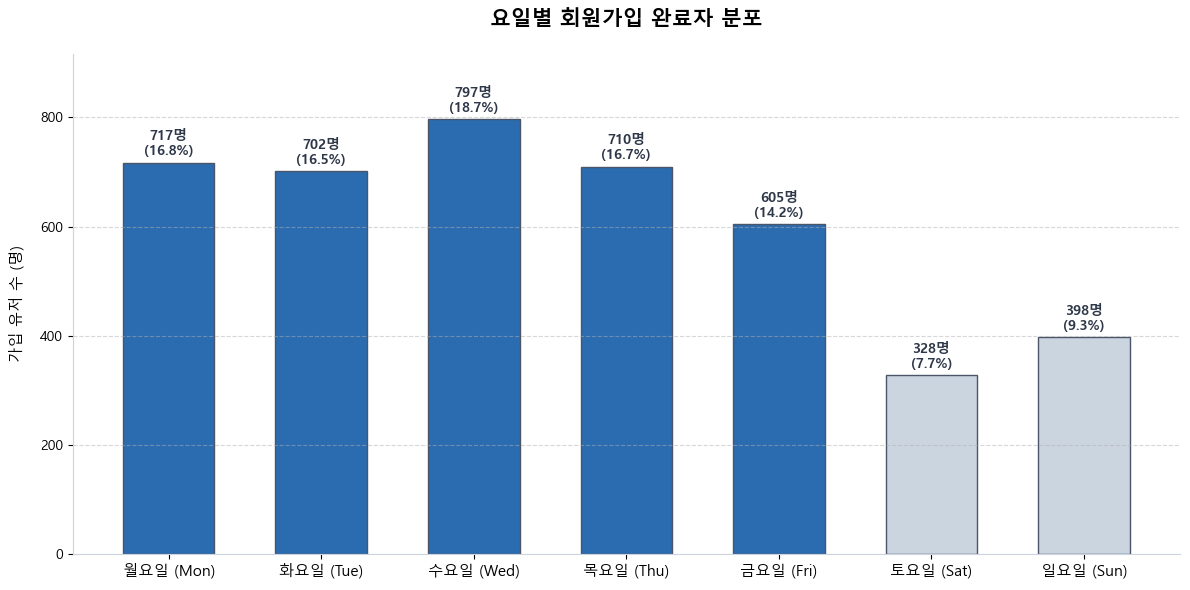

In [26]:
import platform
import matplotlib.pyplot as plt
import pandas as pd

# 데이터프레임 준비
df_day = signup_done_df.copy() if "df_done" in locals() else signup_leadtime.copy()

# ==========================================
# 1. 폰트 및 스타일 초기화
# ==========================================
plt.clf()
if platform.system() == "Windows":
    plt.rc("font", family="Malgun Gothic")
elif platform.system() == "Darwin":  # Mac
    plt.rc("font", family="AppleGothic")
plt.rcParams["axes.unicode_minus"] = False

# ==========================================
# 2. 시계열 데이터 가공 (요일 추출 및 정렬)
# ==========================================
# datetime 형태로 확실하게 변환
df_day["signup_done_time"] = pd.to_datetime(df_day["signup_done_time"])

# 요일 코드 추출 (0: 월요일, 1: 화요일, ..., 6: 일요일)
df_day["signup_dayofweek"] = df_day["signup_done_time"].dt.dayofweek

# 요일 숫자를 예쁜 한글 이름으로 매칭하기 위한 딕셔너리
day_labels = {
    0: "월요일 (Mon)",
    1: "화요일 (Tue)",
    2: "수요일 (Wed)",
    3: "목요일 (Thu)",
    4: "금요일 (Fri)",
    5: "토요일 (Sat)",
    6: "일요일 (Sun)",
}

# 요일별 고유 유저 수 카운트 후 월~일 순서대로 정렬
weekday_trend = (
    df_day.groupby("signup_dayofweek")["user_uuid"].nunique().sort_index()
)
weekday_trend.index = weekday_trend.index.map(day_labels)

# ==========================================
# 3. 요일별 세로 막대그래프(Bar Chart) 시각화
# ==========================================
plt.figure(figsize=(12, 6))

# 평일과 주말을 시각적으로 구분하기 위한 컬러 배열 설계
# 월~금: 신뢰감을 주는 블루 계열 / 토~일: 휴식을 뜻하는 연한 회색 계열
colors = ["#2b6cb0", "#2b6cb0", "#2b6cb0", "#2b6cb0", "#2b6cb0", "#cbd5e0", "#cbd5e0"]

bars = plt.bar(
    weekday_trend.index,
    weekday_trend.values,
    color=colors,
    edgecolor="#4a5568",
    width=0.6,
)

# 그래프 타이틀 및 축 설정
plt.title(
    "요일별 회원가입 완료자 분포",
    fontsize=15,
    fontweight="bold",
    pad=20,
)
plt.ylabel("가입 유저 수 (명)", fontsize=11, labelpad=10)
plt.xticks(fontsize=11)
plt.yticks(fontsize=10)

# 막대 상단에 정확한 수치 및 비중(%) 표시
total_users = weekday_trend.sum()
for bar in bars:
    height = bar.get_height()
    pct = (height / total_users) * 100
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + (max(weekday_trend.values) * 0.01),
        f"{height:,}명\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#2d3748",
    )

# 레이아웃 외곽선 및 그리드 정리
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#cbd5e0")
ax.spines["bottom"].set_color("#cbd5e0")
plt.grid(axis="y", linestyle="--", alpha=0.5)

# 상단 텍스트 공간 확보를 위해 Y축 범위를 최대값의 15% 위로 상향 조정
plt.ylim(0, max(weekday_trend.values) * 1.15)

plt.tight_layout()
plt.show()

### 5-3. 시간대별 가입 집중도 (KST 기준, 히트맵)

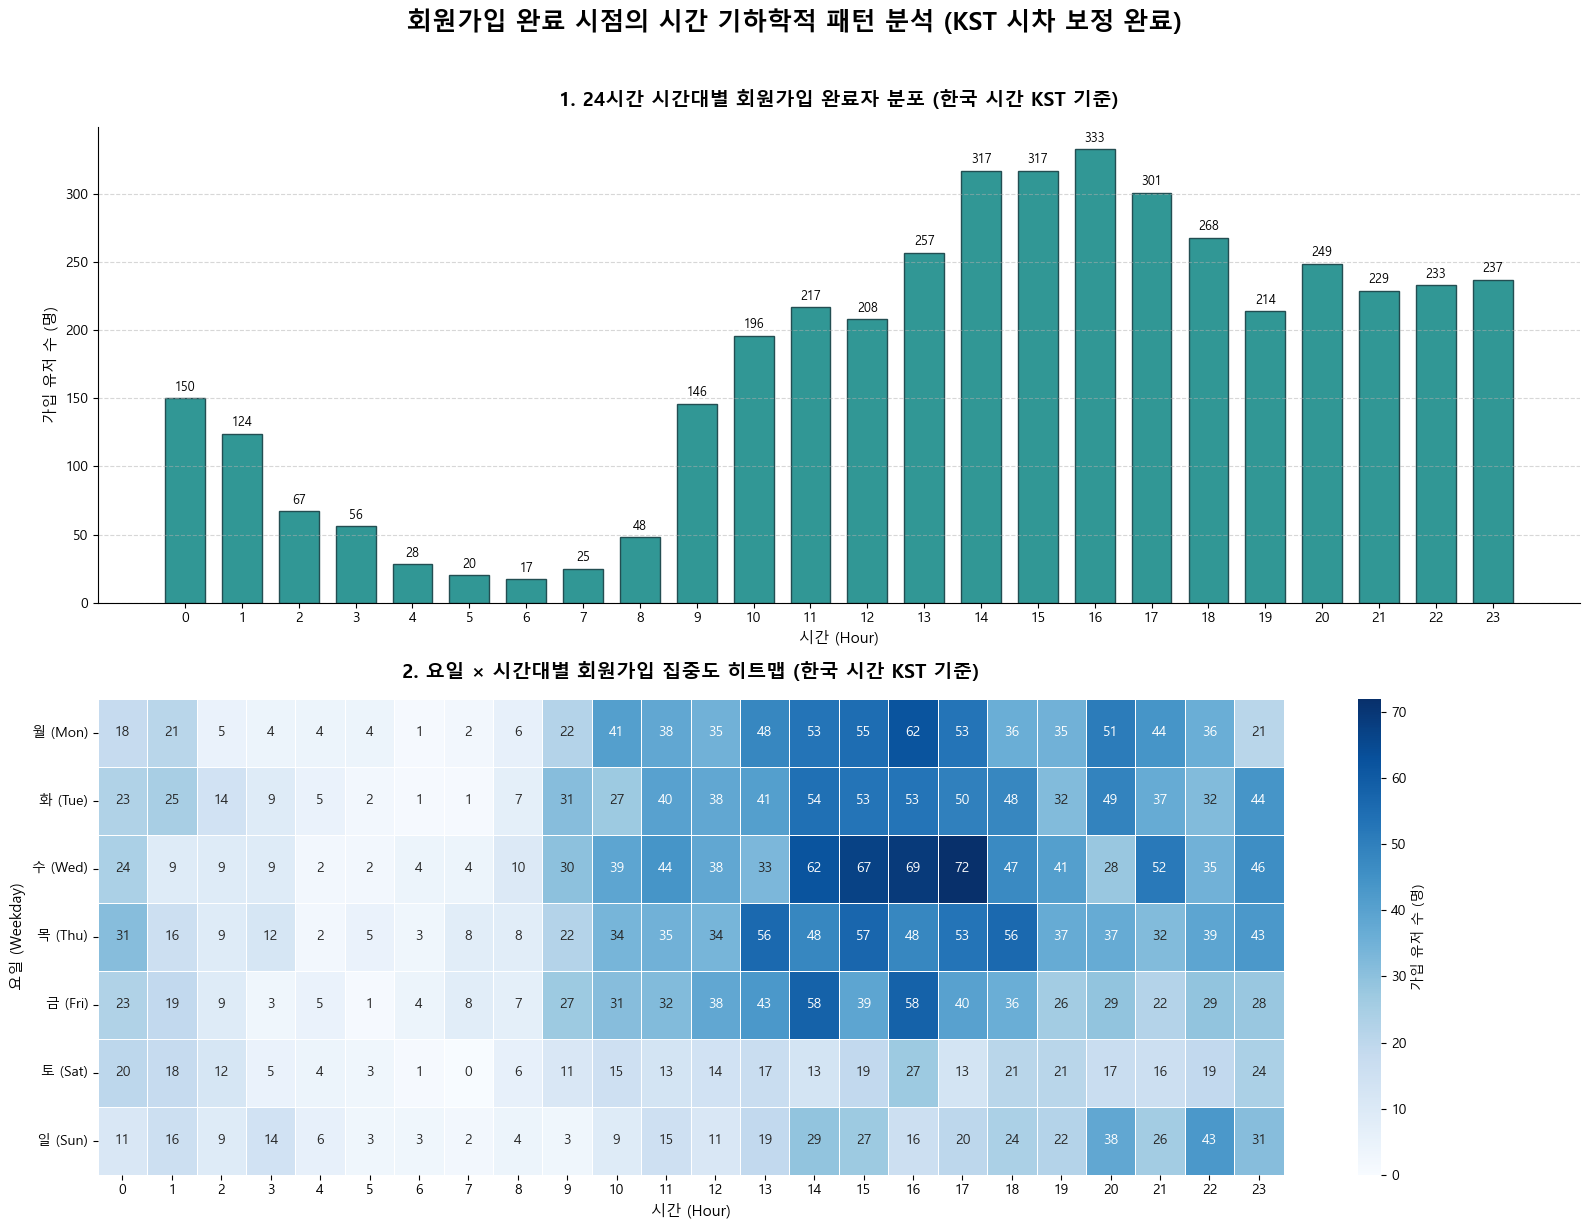

In [27]:
import platform
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 0. 데이터프레임 복사
df_time = df_done.copy() if "df_done" in locals() else signup_leadtime.copy()

# ==========================================
# 1. 폰트 및 스타일 초기화
# ==========================================
plt.clf()
if platform.system() == "Windows":
    plt.rc("font", family="Malgun Gothic")
elif platform.system() == "Darwin":  # Mac
    plt.rc("font", family="AppleGothic")
plt.rcParams["axes.unicode_minus"] = False

# ==========================================
# 2. ★ 핵심: UTC 시간을 한국 시간(KST)으로 변환 ★
# ==========================================
# 1) 기존 문자열 데이터를 datetime 객체로 변환
df_time["signup_done_time"] = pd.to_datetime(df_time["signup_done_time"])

# 2) 타임존이 없거나 문자열에 UTC가 명시된 경우, UTC로 기준을 잡은 뒤 ➔ Asia/Seoul(KST)로 변환
if df_time["signup_done_time"].dt.tz is None:
    df_time["signup_done_time_kst"] = df_time["signup_done_time"].dt.localize("UTC").dt.tz_convert("Asia/Seoul")
else:
    df_time["signup_done_time_kst"] = df_time["signup_done_time"].dt.tz_convert("Asia/Seoul")

# 3) 한국 시간(KST) 기준으로 시간(Hour) 및 요일(Dayofweek)을 다시 추출 ✨
df_time["signup_hour"] = df_time["signup_done_time_kst"].dt.hour
df_time["signup_dayofweek"] = df_time["signup_done_time_kst"].dt.dayofweek

# ==========================================
# 3. 데이터 집계 (KST 기준)
# ==========================================
# 1) 시간대별 가입자 수 집계
hourly_counts = df_time.groupby("signup_hour")["user_uuid"].nunique()
# 0시부터 23시까지 빈 칸이 없도록 채워줌
hourly_counts = hourly_counts.reindex(range(24), fill_value=0)

# 2) 요일 x 시간대 크로스탭 매트릭스 생성
heatmap_data = pd.crosstab(
    index=df_time["signup_dayofweek"], 
    columns=df_time["signup_hour"], 
    values=df_time["user_uuid"], 
    aggfunc="nunique"
).fillna(0)

# 0~6 요일 인덱스와 0~23시 컬럼이 완벽히 매칭되도록 보장
heatmap_data = heatmap_data.reindex(index=range(7), columns=range(24), fill_value=0)

# 인덱스 요일 이름을 보기 좋게 한글명으로 변경
day_names = ["월 (Mon)", "화 (Tue)", "수 (Wed)", "목 (Thu)", "금 (Fri)", "토 (Sat)", "일 (Sun)"]
heatmap_data.index = day_names

# ==========================================
# 4. 2행 1열 서브플롯 시각화 (KST 반영)
# ==========================================
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# --- [상단 차트: 한국 시간 기준 24시간 가입자 분포] ---
axes[0].bar(hourly_counts.index, hourly_counts.values, color="#319795", edgecolor="#234e52", width=0.7)
axes[0].set_title("1. 24시간 시간대별 회원가입 완료자 분포 (한국 시간 KST 기준)", fontsize=14, fontweight="bold", pad=15)
axes[0].set_xlabel("시간 (Hour)", fontsize=11)
axes[0].set_ylabel("가입 유저 수 (명)", fontsize=11)
axes[0].set_xticks(range(24))
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

# 상단 막대에 수치 라벨 추가
for i, val in enumerate(hourly_counts.values):
    if val > 0:
        axes[0].text(i, val + (max(hourly_counts.values) * 0.01), f"{val}", ha="center", va="bottom", fontsize=9)

# --- [하단 차트: 한국 시간 기준 요일 × 시간대별 히트맵] ---
sns.heatmap(
    heatmap_data,
    cmap="Blues",
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    ax=axes[1],
    cbar_kws={"label": "가입 유저 수 (명)"}
)
axes[1].set_title("2. 요일 × 시간대별 회원가입 집중도 히트맵 (한국 시간 KST 기준)", fontsize=14, fontweight="bold", pad=15)
axes[1].set_xlabel("시간 (Hour)", fontsize=11)
axes[1].set_ylabel("요일 (Weekday)", fontsize=11)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)

# 테두리 정리
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

plt.suptitle("회원가입 완료 시점의 시간 기하학적 패턴 분석 (KST 시차 보정 완료)", fontsize=18, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 5-4. 회원가입 완료 시계열 및 시간 기하학적 패턴 분석

#### 1. 종합 요약
* **장기 우하향 추세와 계절성:** 2022년 초를 기점으로 전체 가입자 수는 지속적인 감소세에 있으나, 연말(12월) 및 연초(1~3월) 구직 성수기 시즌에는 일시적으로 반등하는 계절성 패턴이 뚜렷함
* **직장인 루틴 중심의 가입 행동:** 주말보다는 평일(월~금), 새벽보다는 주간 업무 시간대(오전 10시~오후 5시)에 가입이 집중되는 전형적인 'B2B/업무 목적형 라이프사이클'을 보임

---

#### 2. 시계열/시간대별 핵심 분석

#### [월별 추이] 2개년 장기 감소 및 특정 시점의 반등
* **현황:** 2022년 1월 peak(313명) 이후 2023년 11월(95명)까지 장기 우하향 곡선을 그림. (2023년 12월의 18명은 데이터 수집 기간 미달로 인한 착시로 해석됨) 중간에 2022년 3월(266명), 2022년 12월(220명), 2023년 2월(195명)에 일시적 스파이크가 발생함
* **해석:** 전반적인 신규 유입 모수가 줄어드는 경고 신호가 감지됨. 다만, 상·하반기 주요 공채 및 이직이 활발한 '연말연시/연초 시즌'에는 가입자가 다시 튀어 오르는 특성이 있어, 이 시기에 맞춘 전사적 마케팅 집중이 필요함

#### [요일 및 시간대] 평일 근무 시간과 수요일의 집중 현황
* **현황:** 요일별로는 수요일(797명, 18.7%)이 가장 높고 주말(토·일합산 17.0%)은 급격히 하락함. 시간대별로는 14시~16시(각 317명~333명)가 피크이며, 0시~1시 야간 가입자(각 124명~150명)도 일부 존재함
* **해석:** 유저들은 주말에 여유롭게 가입하기보다, 평일 중에서도 한주의 중심인 **'수요일 오후 2시~4시'**에 집중적으로 구직 행동을 취함. 히트맵을 보면 수요일 오후 5시(67명)와 7시(72명) 역시 일주일 중 가장 높은 집중도를 보여, 해당 요일에 구직 의지가 가장 극대화됨을 입증함

---

#### 3. 핵심 제언 (Action Items)

1. **타깃 발송 타이밍 조준 (수요일 골든아워 활용):** 주말이나 월요일 브리핑 시간을 피해, 데이터상 유저 활성도가 가장 검증된 **'수요일 오전 11시' 또는 '수요일 오후 2시'**에 맞추어 맞춤형 채용 공고 이메일(CRM)을 발송할 것. 유저가 스크린 앞에 앉아 있는 최적의 타이밍을 저격해야 오픈율과 가입 전환율을 극대화할 수 있음
2. **시즌별 마케팅 예산 및 캠페인 재분배:** 전체적인 가입 추이가 우하향하고 있으므로 사계절 내내 동일한 예산을 태우는 것은 비효율적임. 가입 반등 모멘텀이 증명된 **11월 말~2월 말(연말연시 공백기 및 상반기 공채 준비기)**에 리소스를 집중 투여하여 유입 효율을 방어해야 함

## 6. 특성 분석 1. 북마크

In [28]:
query = """
WITH logs AS (
    SELECT user_uuid, `timestamp`, URL, response_code
    FROM log_2022
    WHERE user_uuid IS NOT NULL
      AND response_code NOT IN (400,404,500)

    UNION ALL

    SELECT user_uuid, `timestamp`, URL, response_code
    FROM log_2023
    WHERE user_uuid IS NOT NULL
      AND response_code NOT IN (400,404,500)
),

step_detail_users AS (
    SELECT user_uuid, MIN(`timestamp`) AS detail_time
    FROM logs
    WHERE URL LIKE '%%signup/detail%%'
    GROUP BY user_uuid
),

step1_users AS (
    SELECT l.user_uuid, MIN(l.`timestamp`) AS step1_time
    FROM logs l
    JOIN step_detail_users d
      ON l.user_uuid = d.user_uuid
     AND l.`timestamp` >= d.detail_time
    WHERE l.URL LIKE '%%signup/step1%%'
    GROUP BY l.user_uuid
),

step2_users AS (
    SELECT l.user_uuid, MIN(l.`timestamp`) AS step2_time
    FROM logs l
    JOIN step1_users s1
      ON l.user_uuid = s1.user_uuid
     AND l.`timestamp` >= s1.step1_time
    WHERE l.URL LIKE '%%signup/step2%%'
    GROUP BY l.user_uuid
),

signup_done_users AS (
    SELECT
        l.user_uuid,
        MIN(l.`timestamp`) AS done_time
    FROM logs l
    JOIN step2_users s2
      ON l.user_uuid = s2.user_uuid
     AND l.`timestamp` >= s2.step2_time
    WHERE l.URL LIKE '%%signup/step3/done%%'
      AND l.response_code = 200
    GROUP BY l.user_uuid
),

bookmark_first AS (
    SELECT
        user_uuid,
        MIN(cdate) AS first_bookmark_time
    FROM JobBookmark
    GROUP BY user_uuid
)

SELECT
    CASE
        WHEN b.first_bookmark_time < s.done_time
        THEN 'bookmark_before_signup'
        ELSE 'no_bookmark_before_signup'
    END AS bookmark_group,

    COUNT(*) AS signup_users,

    ROUND(
        COUNT(*) * 100.0 /
        SUM(COUNT(*)) OVER(),
        2
    ) AS ratio

FROM signup_done_users s

LEFT JOIN bookmark_first b
    ON s.user_uuid = b.user_uuid

GROUP BY bookmark_group
"""

bookmark_before_signup_df = pd.read_sql(query, engine)

bookmark_before_signup_df

### 6-1. 북마크 타이밍별 분포 (가입 전 / 퍼널 구간별 / 가입 후)

In [29]:
query = signup_cte + """
SELECT
    CASE
        WHEN s3.user_uuid IS NOT NULL THEN '가입완료'
        ELSE '가입미완료'
    END AS signup_status,

    COUNT(DISTINCT d.user_uuid) AS users,

    COUNT(DISTINCT jb.user_uuid) AS bookmarked_users,

    COUNT(DISTINCT CONCAT(jb.user_uuid, '-', jb.job_uuid)) AS total_bookmarks,

    ROUND(
        COUNT(DISTINCT jb.user_uuid) * 100.0
        / COUNT(DISTINCT d.user_uuid),
        2
    ) AS bookmark_user_rate,

    ROUND(
        COUNT(DISTINCT CONCAT(jb.user_uuid, '-', jb.job_uuid)) * 1.0
        / COUNT(DISTINCT d.user_uuid),
        2
    ) AS bookmarks_per_user

FROM step_detail_users d

LEFT JOIN step3_done_users s3
    ON d.user_uuid = s3.user_uuid

LEFT JOIN jobbookmark jb
    ON d.user_uuid = jb.user_uuid

GROUP BY
    CASE
        WHEN s3.user_uuid IS NOT NULL THEN '가입완료'
        ELSE '가입미완료'
    END;
"""
bookmark_by_signup_df = pd.read_sql(query, engine)
bookmark_by_signup_df

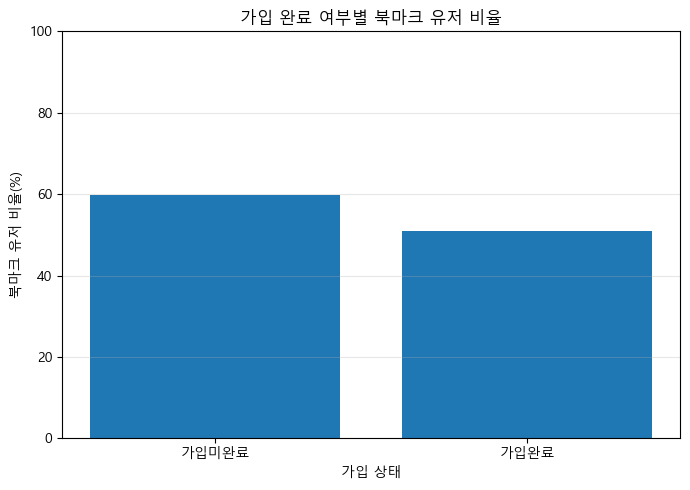

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(
    bookmark_by_signup_df['signup_status'],
    bookmark_by_signup_df['bookmark_user_rate']
)

plt.title('가입 완료 여부별 북마크 유저 비율')
plt.xlabel('가입 상태')
plt.ylabel('북마크 유저 비율(%)')

plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [31]:
# 중복 북마크 여부 조회
query = signup_cte + """
SELECT
    -- 전체 북마크
    COUNT(*) AS total_rows,
    -- 고유 북마크
    COUNT(DISTINCT CONCAT(user_uuid, '-', job_uuid)) AS distinct_bookmarks
FROM jobbookmark;
"""
pd.read_sql(query, engine)

In [32]:
query = signup_cte + """
, bookmark_timing AS (
    SELECT
        d.user_uuid,
        jb.job_uuid,
        jb.cdate AS bookmark_time,

        CASE
            WHEN jb.cdate >= d.detail_time
             AND s1.step1_time IS NOT NULL
             AND jb.cdate < s1.step1_time
            THEN '1_detail~step1 사이'

            WHEN jb.cdate >= s1.step1_time
             AND s2.step2_time IS NOT NULL
             AND jb.cdate < s2.step2_time
            THEN '2_step1~step2 사이'

            WHEN jb.cdate >= s2.step2_time
             AND s3.done_time IS NOT NULL
             AND jb.cdate < s3.done_time
            THEN '3_step2~done 사이'

            WHEN s3.done_time IS NOT NULL
             AND jb.cdate >= s3.done_time
            THEN '4_done 이후'

            ELSE '퍼널 구간 외'
        END AS bookmark_timing

    FROM step_detail_users d

    LEFT JOIN step1_users s1
        ON d.user_uuid = s1.user_uuid

    LEFT JOIN step2_users s2
        ON d.user_uuid = s2.user_uuid

    LEFT JOIN step3_done_users s3
        ON d.user_uuid = s3.user_uuid

    LEFT JOIN jobbookmark jb
        ON d.user_uuid = jb.user_uuid
)

SELECT
    bookmark_timing,

    COUNT(DISTINCT user_uuid) AS bookmarked_users,
-- ----------고유북마크수 : 같은 사람이 같은 공고를 북마크한 것은 1건으로 처리 (증복제거)----------
-- ----------ex. 유저A - 공고1 / 유저A - 공고2 -> 2건
    COUNT(DISTINCT CONCAT(user_uuid, '-', job_uuid)) AS total_bookmarks,

    ROUND(
        COUNT(DISTINCT CONCAT(user_uuid, '-', job_uuid)) * 1.0
        / COUNT(DISTINCT user_uuid),
        2
    ) AS bookmarks_per_bookmarked_user

FROM bookmark_timing
WHERE job_uuid IS NOT NULL
GROUP BY bookmark_timing
ORDER BY bookmark_timing;
"""

bookmark_timing_df = pd.read_sql(query, engine)
bookmark_timing_df

In [33]:
# detail 진입 전 북마크한 유저 수 
query = signup_cte + """
SELECT
    COUNT(DISTINCT jb.user_uuid) AS users
FROM step_detail_users d
JOIN jobbookmark jb
    ON d.user_uuid = jb.user_uuid
WHERE jb.cdate < d.detail_time;
"""
pd.read_sql(query, engine)

##### 해석

- 가입 단계 사이 구간에서는 북마크가 거의 발생하지 않음
- '퍼널 구간 외' 북마크는 대부분 가입 전 북마크에 해당함

### 6-2. 가입 전 북마크 경험 여부와 가입 완료의 관계

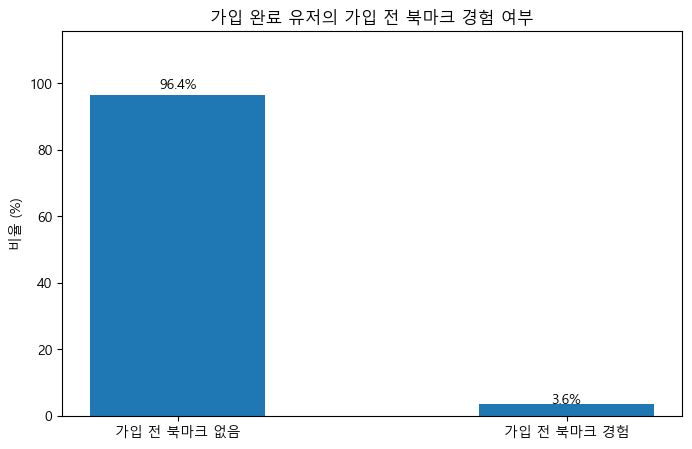

In [34]:
import matplotlib.pyplot as plt

plot_df = bookmark_before_signup_df.copy()

label_map = {
    'bookmark_before_signup': '가입 전 북마크 경험',
    'no_bookmark_before_signup': '가입 전 북마크 없음'
}

plot_df['label'] = plot_df['bookmark_group'].map(label_map)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    plot_df['label'],
    plot_df['ratio'],
    width=0.45
)

plt.ylim(0, plot_df['ratio'].max() * 1.2)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height * 1.02,
        f'{height:.1f}%',
        ha='center'
    )

plt.title('가입 완료 유저의 가입 전 북마크 경험 여부')
plt.xlabel('')
plt.ylabel('비율 (%)')

plt.show()

In [35]:
# 참고 : 회원가입 후 북마크 한 유저 수 vs 북마크 안한 유저 수
query = """
WITH logs AS (
    SELECT user_uuid, `timestamp`, URL, response_code
    FROM log_2022
    WHERE user_uuid IS NOT NULL
      AND response_code NOT IN (400,404,500)

    UNION ALL

    SELECT user_uuid, `timestamp`, URL, response_code
    FROM log_2023
    WHERE user_uuid IS NOT NULL
      AND response_code NOT IN (400,404,500)
),

step_detail_users AS (
    SELECT user_uuid, MIN(`timestamp`) AS detail_time
    FROM logs
    WHERE URL LIKE '%%signup/detail%%'
    GROUP BY user_uuid
),

step1_users AS (
    SELECT l.user_uuid, MIN(l.`timestamp`) AS step1_time
    FROM logs l
    JOIN step_detail_users d
      ON l.user_uuid = d.user_uuid
     AND l.`timestamp` >= d.detail_time
    WHERE l.URL LIKE '%%signup/step1%%'
    GROUP BY l.user_uuid
),

step2_users AS (
    SELECT l.user_uuid, MIN(l.`timestamp`) AS step2_time
    FROM logs l
    JOIN step1_users s1
      ON l.user_uuid = s1.user_uuid
     AND l.`timestamp` >= s1.step1_time
    WHERE l.URL LIKE '%%signup/step2%%'
    GROUP BY l.user_uuid
),

signup_done_users AS (
    SELECT
        l.user_uuid,
        MIN(l.`timestamp`) AS done_time
    FROM logs l
    JOIN step2_users s2
      ON l.user_uuid = s2.user_uuid
     AND l.`timestamp` >= s2.step2_time
    WHERE l.URL LIKE '%%signup/step3/done%%'
      AND l.response_code = 200
    GROUP BY l.user_uuid
),

bookmark_after_signup AS (
    SELECT DISTINCT
        s.user_uuid
    FROM signup_done_users s
    JOIN JobBookmark jb
      ON s.user_uuid = jb.user_uuid
     AND jb.cdate > s.done_time
)

SELECT
    CASE
        WHEN b.user_uuid IS NOT NULL THEN 'signup_after_bookmark_user'
        ELSE 'signup_after_no_bookmark_user'
    END AS bookmark_after_signup_group,
    COUNT(DISTINCT s.user_uuid) AS user_count
FROM signup_done_users s
LEFT JOIN bookmark_after_signup b
    ON s.user_uuid = b.user_uuid
GROUP BY bookmark_after_signup_group
ORDER BY user_count DESC
"""

bookmark_after_signup_df = pd.read_sql(query, engine)
bookmark_after_signup_df

### 6-3. 전체 북마크 대비 동일 공고 지원 전환율

In [36]:
bookmark_cte = signup_cte + """
-- ---------- 가입 완료 후 북마크 한 유저 ----------
, signup_bookmark_users AS (

    SELECT
        s3.user_uuid,
        jb.job_uuid,
        jb.cdate AS bookmark_time
    FROM step3_done_users s3

    INNER JOIN jobbookmark jb
        ON s3.user_uuid = jb.user_uuid

)
"""

### 전체유저 대상 동일공고 지원율

In [37]:
query = """
WITH bookmark_apply AS (

    SELECT DISTINCT
        jb.user_uuid,
        jb.job_uuid
    FROM jobbookmark jb

    INNER JOIN application a
        ON jb.user_uuid = a.user_uuid
       AND jb.job_uuid = a.job_uuid
       AND a.cdate >= jb.cdate

)

SELECT

    COUNT(DISTINCT CONCAT(jb.user_uuid, '-', jb.job_uuid))
        AS bookmarked_jobs,

    COUNT(DISTINCT CONCAT(ba.user_uuid, '-', ba.job_uuid))
        AS applied_after_bookmark_jobs,

    ROUND(
        COUNT(DISTINCT CONCAT(ba.user_uuid, '-', ba.job_uuid))
        * 100.0
        / COUNT(DISTINCT CONCAT(jb.user_uuid, '-', jb.job_uuid)),
        2
    ) AS bookmark_to_apply_rate

FROM jobbookmark jb

LEFT JOIN bookmark_apply ba
    ON jb.user_uuid = ba.user_uuid
   AND jb.job_uuid = ba.job_uuid;
"""

bookmark_to_apply_total_df = pd.read_sql(query, engine)
bookmark_to_apply_total_df

### 가입자 대상 동일공고 지원율

In [38]:
query = bookmark_cte + """
, bookmark_apply AS (

    SELECT DISTINCT
        sb.user_uuid,
        sb.job_uuid
    FROM signup_bookmark_users sb
    INNER JOIN application a
        -- 유저 아이디와 공고 아이디가 모두 같을 것으로 조건 제한
        ON sb.user_uuid = a.user_uuid
       AND sb.job_uuid = a.job_uuid
       -- 북마크한 시간 이후 지원한 경우로 조건 제한
       AND a.cdate >= sb.bookmark_time
)

SELECT
    COUNT(DISTINCT CONCAT(sb.user_uuid, '-', sb.job_uuid)) AS bookmarked_jobs,

    COUNT(DISTINCT CONCAT(ba.user_uuid, '-', ba.job_uuid)) AS applied_after_bookmark_jobs,

    ROUND(
        COUNT(DISTINCT CONCAT(ba.user_uuid, '-', ba.job_uuid)) * 100.0
        / COUNT(DISTINCT CONCAT(sb.user_uuid, '-', sb.job_uuid)),
        2
    ) AS bookmark_to_apply_rate

FROM signup_bookmark_users sb

LEFT JOIN bookmark_apply ba
    ON sb.user_uuid = ba.user_uuid
   AND sb.job_uuid = ba.job_uuid;
"""

bookmark_to_apply_signup_df = pd.read_sql(query, engine)
bookmark_to_apply_signup_df

### 6-4. 가입 완료 후 북마크의 전환율 비교 (전체 대비 2.3배)

In [39]:
compare_df = pd.DataFrame({
    'group': ['전체 북마크', '가입완료 후 북마크'],
    'rate': [
        bookmark_to_apply_total_df.loc[0, 'bookmark_to_apply_rate'],
        bookmark_to_apply_signup_df.loc[0, 'bookmark_to_apply_rate']
    ]
})

compare_df

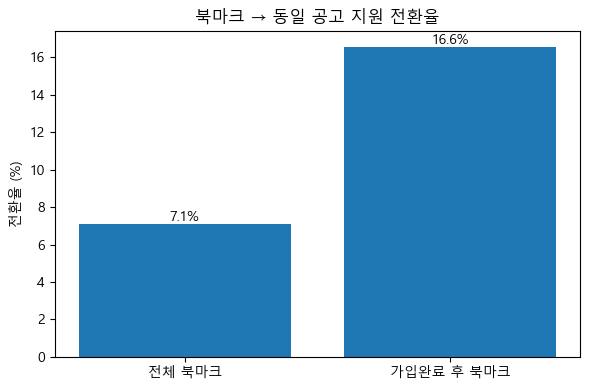

In [40]:
plt.figure(figsize=(6,4))

bars = plt.bar(
    compare_df['group'],
    compare_df['rate']
)

plt.title('북마크 → 동일 공고 지원 전환율')
plt.ylabel('전환율 (%)')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():.1f}%',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

## 7. 특성 분석 2. 가입 유도 공고 특성

- 유저가 어떤 공고를 조회했는지는 파악 불가함
- 가입 전 북마크한 공고를 기준으로 공고 특성 살펴봄

In [41]:
query = """
WITH logs AS (
    SELECT user_uuid, `timestamp`, URL, response_code
    FROM log_2022
    WHERE user_uuid IS NOT NULL
      AND response_code NOT IN (400,404,500)

    UNION ALL

    SELECT user_uuid, `timestamp`, URL, response_code
    FROM log_2023
    WHERE user_uuid IS NOT NULL
      AND response_code NOT IN (400,404,500)
),

step_detail_users AS (
    SELECT user_uuid, MIN(`timestamp`) AS detail_time
    FROM logs
    WHERE URL LIKE '%%signup/detail%%'
    GROUP BY user_uuid
),

step1_users AS (
    SELECT l.user_uuid, MIN(l.`timestamp`) AS step1_time
    FROM logs l
    JOIN step_detail_users d
      ON l.user_uuid = d.user_uuid
     AND l.`timestamp` >= d.detail_time
    WHERE l.URL LIKE '%%signup/step1%%'
    GROUP BY l.user_uuid
),

step2_users AS (
    SELECT l.user_uuid, MIN(l.`timestamp`) AS step2_time
    FROM logs l
    JOIN step1_users s1
      ON l.user_uuid = s1.user_uuid
     AND l.`timestamp` >= s1.step1_time
    WHERE l.URL LIKE '%%signup/step2%%'
    GROUP BY l.user_uuid
),

signup_done_users AS (
    SELECT
        l.user_uuid,
        MIN(l.`timestamp`) AS done_time
    FROM logs l
    JOIN step2_users s2
      ON l.user_uuid = s2.user_uuid
     AND l.`timestamp` >= s2.step2_time
    WHERE l.URL LIKE '%%signup/step3/done%%'
      AND l.response_code = 200
    GROUP BY l.user_uuid
),

bookmark_before_signup AS (
    SELECT DISTINCT
        s.user_uuid,
        jb.job_uuid
    FROM signup_done_users s
    JOIN JobBookmark jb
      ON s.user_uuid = jb.user_uuid
     AND jb.cdate < s.done_time
)

SELECT
    j.job_field,
    j.career_type_string,

    CASE
        WHEN j.allow_remote = 1 THEN '원격가능'
        ELSE '원격불가'
    END AS remote_type,

    CASE
        WHEN j.can_show_salary = 1 THEN '연봉공개'
        ELSE '연봉비공개'
    END AS salary_type,

    COUNT(DISTINCT b.user_uuid) AS signup_users,
    COUNT(DISTINCT b.job_uuid) AS job_count

FROM bookmark_before_signup b
JOIN Job j
    ON b.job_uuid = j.job_uuid

GROUP BY
    j.job_field,
    j.career_type_string,
    remote_type,
    salary_type

ORDER BY signup_users DESC
LIMIT 30
"""

job_feature_df = pd.read_sql(query, engine)

job_feature_df

### 7-1. 직무 분야별 가입 유도 공고 현황

In [42]:
query = """
WITH logs AS (
    SELECT user_uuid, `timestamp`, URL, response_code
    FROM log_2022
    WHERE user_uuid IS NOT NULL
      AND response_code NOT IN (400,404,500)

    UNION ALL

    SELECT user_uuid, `timestamp`, URL, response_code
    FROM log_2023
    WHERE user_uuid IS NOT NULL
      AND response_code NOT IN (400,404,500)
),

step_detail_users AS (
    SELECT user_uuid, MIN(`timestamp`) AS detail_time
    FROM logs
    WHERE URL LIKE '%%signup/detail%%'
    GROUP BY user_uuid
),

step1_users AS (
    SELECT l.user_uuid, MIN(l.`timestamp`) AS step1_time
    FROM logs l
    JOIN step_detail_users d
      ON l.user_uuid = d.user_uuid
     AND l.`timestamp` >= d.detail_time
    WHERE l.URL LIKE '%%signup/step1%%'
    GROUP BY l.user_uuid
),

step2_users AS (
    SELECT l.user_uuid, MIN(l.`timestamp`) AS step2_time
    FROM logs l
    JOIN step1_users s1
      ON l.user_uuid = s1.user_uuid
     AND l.`timestamp` >= s1.step1_time
    WHERE l.URL LIKE '%%signup/step2%%'
    GROUP BY l.user_uuid
),

signup_done_users AS (
    SELECT
        l.user_uuid,
        MIN(l.`timestamp`) AS done_time
    FROM logs l
    JOIN step2_users s2
      ON l.user_uuid = s2.user_uuid
     AND l.`timestamp` >= s2.step2_time
    WHERE l.URL LIKE '%%signup/step3/done%%'
      AND l.response_code = 200
    GROUP BY l.user_uuid
),

bookmark_before_signup AS (
    SELECT DISTINCT
        s.user_uuid,
        jb.job_uuid
    FROM signup_done_users s
    JOIN JobBookmark jb
      ON s.user_uuid = jb.user_uuid
     AND jb.cdate < s.done_time
)

SELECT
    j.job_field,
    COUNT(DISTINCT b.user_uuid) AS signup_users
FROM bookmark_before_signup b
JOIN Job j
  ON b.job_uuid = j.job_uuid
GROUP BY j.job_field
ORDER BY signup_users DESC
"""

job_field_df = pd.read_sql(query, engine)
job_field_df

- SW개발 직무 중심으로 가입이 유도되는 경향 (직무별 가입 유저 수, 중복 제거 기준)

In [43]:
job_field_count_df = (
    job_feature_df
    .groupby('job_field', as_index=False)['signup_users']
    .sum()
    .sort_values('signup_users', ascending=False)
)

job_field_count_df

- 중복 집계 기준으로도 SW개발 직무 비중이 가장 높음

### 7-2. 경력 유형 / 원격근무 / 연봉 공개 여부별 분석

### 경력 유형별

In [44]:
career_count_df = (
    job_feature_df
    .groupby('career_type_string', as_index=False)['signup_users']
    .sum()
    .sort_values('signup_users', ascending=False)
)

career_count_df

### 원격근무

In [45]:
remote_count_df = (
    job_feature_df
    .groupby('remote_type', as_index=False)['signup_users']
    .sum()
    .sort_values('signup_users', ascending=False)
)

remote_count_df

### 연봉공개여부

In [46]:
salary_count_df = (
    job_feature_df
    .groupby('salary_type', as_index=False)['signup_users']
    .sum()
    .sort_values('signup_users', ascending=False)
)

salary_count_df

- 북마크는 크게 유입 요인으로 작용하지는 않음
- 다만, 본 사이트는 sw개발 직무 및 경력 중심으로 유용하게 사용되는 듯함

### 7-3. 기업 규모별 공고 구성 패턴

In [47]:
query = """
SELECT
    c.company_uuid,
    c.cdate AS company_created_at,
    c.employee_count,
    c.follow_count,
    c.reference_count,

    j.job_uuid,
    j.cdate AS job_created_at,
    j.job_field,
    j.career_type_string,
    j.start_date,
    j.end_date,
    CASE
        WHEN j.allow_remote = 1 THEN '원격가능'
        ELSE '원격불가'
    END AS remote_type,
    CASE
        WHEN j.can_show_salary = 1 THEN '연봉공개'
        ELSE '연봉비공개'
    END AS salary_type

FROM Company c
JOIN Job j
    ON c.company_uuid = j.company_uuid

ORDER BY
    c.company_uuid,
    j.cdate
"""

company_job_df = pd.read_sql(query, engine)
# (데이터 보호: 원본 미리보기 출력 제거)
# company_job_df


In [48]:
company_job_summary_df = (
    company_job_df
    .groupby(
        [
            'employee_count',
            'job_field',
            'career_type_string',
            'remote_type',
            'salary_type'
        ],
        as_index=False
    )
    .agg(
        company_count=('company_uuid', 'nunique'),
        job_count=('job_uuid', 'nunique')
    )
    .sort_values(
        ['employee_count', 'job_count'],
        ascending=[True, False]
    )
)

company_job_summary_df

### 기업 규모별 공고 수

In [49]:
order = [
    '0명',
    '1-10명',
    '11-50명',
    '51-200명',
    '201-500명',
    '501-1000명',
    '1001-5000명',
    '5000명 초과'
]

(
    company_job_df['employee_count']
    .value_counts()
    .reindex(order)
)

In [50]:
ct = pd.crosstab(
    company_job_df['employee_count'],
    company_job_df['career_type_string']
)

ct = ct.reindex(order)

ct

## 8. 종합 인사이트 및 제언

### 8-1. 핵심 발견

- **가입 소요 시간**: 중앙값 2분 16초로 대부분 즉시 가입하지만, 평균은 이상치(최대 671일)의 영향으로 3.1일까지 늘어난다. 절반 이상이 재방문 없이 그 자리에서 가입을 완료한다.
- **유입 경로**: CRM 알림(`notification`)·이메일(`email`)이 가장 큰 유입 채널이며, 채용 공고 페이지를 반복 조회하다 가입하는 탐색형 유입도 존재한다.
- **시계열 패턴**: 2022년 이후 신규 가입은 장기적으로 감소 추세이나 연말·연초 채용 성수기에 반등한다. 평일, 특히 수요일 오후 2~4시에 가입이 집중된다.
- **북마크 행동**: 가입 단계 도중에는 북마크가 거의 발생하지 않고, 대부분 가입 전 또는 가입 후에 발생한다. 가입 완료 후 북마크한 공고의 지원 전환율은 전체 평균 대비 2.3배 높다.
- **가입 유도 공고 특성**: 가입 전 북마크된 공고는 SW개발 직무 비중이 가장 높다. 다만 북마크 자체가 가입의 주요 유인은 아니다.

### 8-2. 제언

| 우선순위 | 액션 | 근거 |
|---|---|---|
| ★★★ | CRM 이메일/알림 UI·개인화 추천 고도화 | 가입 전환의 최대 채널이며 유저당 평균 2.3회 반복 클릭 후 가입 |
| ★★ | 수요일 오후 2~4시 타겟 발송 | 요일·시간대별 가입 집중도가 가장 높은 구간 |
| ★★ | 비회원 공고 조회 시 가입 유도 요소 배치 | 채용 공고 반복 조회 후 가입하는 탐색형 유입 존재 |
| ★ | step1→step2 구간 UX 점검 | 가입 퍼널 내 이탈이 상대적으로 큰 구간 |
